In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")


All libraries installed.


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [3]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                      ║
# ╚═════════════════════════════════════════════════════╝

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — PII COLUMN REGISTRY + STATE MAP                       ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
NEWFIX 2: Define all Personally Identifiable Information (PII) columns
to be dropped from each dataset before any processing begins.

PII columns identified across all 4 datasets:
  SAKIB      : brokered_by (agent/broker name), street (property address),
               prev_sold_date (can identify owner transaction history)
  POLARTECH  : property_url, property_id, broker_id, agent_name,
               agency_name, address, street_name, apartment
  TEXAS 2026 : address, street (if present), agent (if present)
  NEW YORK   : address, street (if present)

Non-PII location columns kept: city, state, zip_code, latitude, longitude
These are geographic but not individually identifying.
"""

# PII columns per dataset (lowercase column names after normalisation)
PII_COLS_SAKIB = [
    "brokered_by",     # agent / broker name — PII
    "street",          # full street address — PII
    "prev_sold_date",  # transaction history — quasi-PII
]

PII_COLS_POLARTECH = [
    "property_url",    # URL can identify listing owner — PII
    "property_id",     # internal ID — quasi-PII
    "broker_id",       # broker identifier — PII
    "agent_name",      # personal name — PII
    "agency_name",     # business name — quasi-PII
    "address",         # full street address — PII
    "street_name",     # partial address — PII
    "apartment",       # unit number — PII
    "agent_phone",     # agent phone number - PII
]

PII_COLS_NLP = [
    "address",         # full address if present — PII
    "street",          # street name — PII
    "agent",           # agent name — PII
    "listing_agent",   # agent name — PII
    "mls_id",          # MLS listing ID — quasi-PII
    "listing_id",      # listing identifier — quasi-PII
]

def drop_pii_columns(df, pii_list, dataset_name):
    """
    Drop PII columns from a DataFrame.
    Reports which columns were found and dropped.
    Only drops columns that actually exist — no error on missing.
    """
    found = [c for c in pii_list if c in df.columns]
    not_found = [c for c in pii_list if c not in df.columns]
    if found:
        df = df.drop(columns=found)
        print(f"  {dataset_name} — PII dropped: {found}")
    if not_found:
        print(f"  {dataset_name} — PII not present (safe): {not_found}")
    return df

# ── STATE MAP ────────────────────────────────────────────────────────────────
STATE_MAP = {
    "ALABAMA":"AL","ALASKA":"AK","ARIZONA":"AZ","ARKANSAS":"AR",
    "CALIFORNIA":"CA","COLORADO":"CO","CONNECTICUT":"CT","DELAWARE":"DE",
    "FLORIDA":"FL","GEORGIA":"GA","HAWAII":"HI","IDAHO":"ID",
    "ILLINOIS":"IL","INDIANA":"IN","IOWA":"IA","KANSAS":"KS",
    "KENTUCKY":"KY","LOUISIANA":"LA","MAINE":"ME","MARYLAND":"MD",
    "MASSACHUSETTS":"MA","MICHIGAN":"MI","MINNESOTA":"MN","MISSISSIPPI":"MS",
    "MISSOURI":"MO","MONTANA":"MT","NEBRASKA":"NE","NEVADA":"NV",
    "NEW HAMPSHIRE":"NH","NEW JERSEY":"NJ","NEW MEXICO":"NM","NEW YORK":"NY",
    "NORTH CAROLINA":"NC","NORTH DAKOTA":"ND","OHIO":"OH","OKLAHOMA":"OK",
    "OREGON":"OR","PENNSYLVANIA":"PA","RHODE ISLAND":"RI","SOUTH CAROLINA":"SC",
    "SOUTH DAKOTA":"SD","TENNESSEE":"TN","TEXAS":"TX","UTAH":"UT",
    "VERMONT":"VT","VIRGINIA":"VA","WASHINGTON":"WA","WEST VIRGINIA":"WV",
    "WISCONSIN":"WI","WYOMING":"WY","DISTRICT OF COLUMBIA":"DC",
}
for abbr in ["AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID",
             "IL","IN","IA","KS","KY","LA","ME","MD","MA","MI","MN","MS",
             "MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK",
             "OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA","WV",
             "WI","WY","DC"]:
    STATE_MAP[abbr] = abbr

def normalise_state(series):
    """Convert any state format to 2-letter abbreviation."""
    return (series.astype(str).str.strip().str.upper()
            .map(lambda x: STATE_MAP.get(x, x)))

# Verify STATE_MAP
test_states = pd.Series(["Texas", "New York", "CA", "florida"])
for raw, norm in zip(test_states, normalise_state(test_states)):
    print(f"  '{raw}' → '{norm}'")
print("State normalisation confirmed ✓")
print("PII column registry defined ✓")


  'Texas' → 'TX'
  'New York' → 'NY'
  'CA' → 'CA'
  'florida' → 'FL'
State normalisation confirmed ✓
PII column registry defined ✓


In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — DOWNLOAD ALL 4 DATASETS                                ║
# ╚══════════════════════════════════════════════════════════════════╝

print("Downloading 4 datasets ...")
path_sakib    = kagglehub.dataset_download("ahmedshahriarsakib/usa-real-estate-dataset")
path_polartech= kagglehub.dataset_download("polartech/500000-us-homes-data-for-sale-properties")
path_texas    = kagglehub.dataset_download("jahnavikachhia23/texas-residential-real-estate-intelligence-2026")
path_newyork  = kagglehub.dataset_download("kanchana1990/new-york-real-estate-data-2026")
print(f"  SAKIB     : {path_sakib}")
print(f"  POLARTECH : {path_polartech}")
print(f"  TEXAS     : {path_texas}")
print(f"  NEW YORK  : {path_newyork}")

100%|██████████| 38.2M/38.2M [00:00<00:00, 46.6MB/s]

Extracting files...


100%|██████████| 34.6M/34.6M [00:00<00:00, 50.6MB/s]

Extracting files...


100%|██████████| 3.46M/3.46M [00:00<00:00, 48.8MB/s]

Extracting files...


100%|██████████| 3.11M/3.11M [00:00<00:00, 152MB/s]

Extracting files...
  SAKIB     : /root/.cache/kagglehub/datasets/ahmedshahriarsakib/usa-real-estate-dataset/versions/25
  POLARTECH : /root/.cache/kagglehub/datasets/polartech/500000-us-homes-data-for-sale-properties/versions/1
  TEXAS     : /root/.cache/kagglehub/datasets/jahnavikachhia23/texas-residential-real-estate-intelligence-2026/versions/1
  NEW YORK  : /root/.cache/kagglehub/datasets/kanchana1990/new-york-real-estate-data-2026/versions/1


In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — LOAD CSV FILES                                        ║
# ╚══════════════════════════════════════════════════════════════════╝

def find_csv(folder):
    for root, dirs, fs in os.walk(folder):
        for f in fs:
            if f.endswith(".csv"):
                return os.path.join(root, f)
    raise FileNotFoundError(f"No CSV in: {folder}")

df_sakib     = pd.read_csv(find_csv(path_sakib),     low_memory=False)
df_polartech = pd.read_csv(find_csv(path_polartech), low_memory=False)
df_texas     = pd.read_csv(find_csv(path_texas),     low_memory=False)
df_newyork   = pd.read_csv(find_csv(path_newyork),   low_memory=False)

for name, df in [("SAKIB",df_sakib),("POLARTECH",df_polartech),
                  ("TEXAS",df_texas),("NEW YORK",df_newyork)]:
    print(f"{name:10s}: {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"  Columns: {list(df.columns)}")

TEXAS_DESC   = "description"
NEWYORK_DESC = "description"

SAKIB     : 2,226,382 rows x 12 cols
  Columns: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']
POLARTECH : 600,000 rows x 28 cols
  Columns: ['property_url', 'property_id', 'address', 'street_name', 'apartment', 'city', 'state', 'latitude', 'longitude', 'postcode', 'price', 'bedroom_number', 'bathroom_number', 'price_per_unit', 'living_space', 'land_space', 'land_space_unit', 'broker_id', 'property_type', 'property_status', 'year_build', 'total_num_units', 'listing_age', 'RunDate', 'agency_name', 'agent_name', 'agent_phone', 'is_owned_by_zillow']
TEXAS     : 12,137 rows x 13 cols
  Columns: ['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built', 'Price_Per_SqFt']
NEW YORK  : 8,273 rows x 11 cols
  Columns: ['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage'

In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — FULL CLEANING AUDIT: SAKIB                            ║
# ╚══════════════════════════════════════════════════════════════════╝
# Shows: dataset size → duplicates → nulls → outliers → skew →
#        MICE imputation → cleaned size at every step

print("=" * 65)
print("CLEANING AUDIT — SAKIB")
print("=" * 65)

df_sakib_clean = df_sakib.copy()
df_sakib_clean.columns = (df_sakib_clean.columns.str.strip().str.lower()
                           .str.replace(r"[\s\-]+","_",regex=True))

BED_COL  = "bed"        if "bed"        in df_sakib_clean.columns else "beds"
BATH_COL = "bath"       if "bath"       in df_sakib_clean.columns else "baths"
SQFT_COL = "house_size" if "house_size" in df_sakib_clean.columns else "sqfoot"
CITY_COL = "city"       if "city"       in df_sakib_clean.columns else None
print(f"Column mapping: bed='{BED_COL}' bath='{BATH_COL}' sqft='{SQFT_COL}' city='{CITY_COL}'")

# STEP 1: Dataset size
print(f"\nSTEP 1 — Dataset Size")
print(f"  Rows     : {df_sakib_clean.shape[0]:,}")
print(f"  Columns  : {df_sakib_clean.shape[1]}")
print(f"  Memory   : {df_sakib_clean.memory_usage(deep=True).sum()/1e6:.1f} MB")

# STEP 2: PII removal
print("\nSTEP 2 — PII REMOVAL:")
df_sakib_clean = drop_pii_columns(df_sakib_clean, PII_COLS_SAKIB, "SAKIB")

# STEP 3: Duplicate rows
n_before = len(df_sakib_clean)
dup_count = df_sakib_clean.duplicated().sum()
print(f"\nSTEP 3 — Duplicate Rows")
print(f"  Exact duplicates found : {dup_count:,}")
df_sakib_clean = df_sakib_clean.drop_duplicates()
print(f"  Rows after removal     : {len(df_sakib_clean):,} (removed {n_before-len(df_sakib_clean):,})")

# STEP 4: Null values
print(f"\nSTEP 4 — Null Values (before imputation)")
null_counts = df_sakib_clean.isnull().sum()
null_pct    = (null_counts / len(df_sakib_clean) * 100).round(2)
null_report = pd.DataFrame({"null_count":null_counts,"null_pct":null_pct})
null_report = null_report[null_report["null_count"]>0].sort_values("null_count",ascending=False)
print(null_report.to_string())
print(f"\n  Total null values: {df_sakib_clean.isnull().sum().sum():,}")

# Drop rows where price or state is null (cannot impute the target or key ID)
n = len(df_sakib_clean)
df_sakib_clean = df_sakib_clean.dropna(subset=["price","state"])
print(f"  Dropped rows with null price/state: {n-len(df_sakib_clean):,}")

# STEP 5: STATE_MAP fix
print(f"\nSTEP 5 — State Name Normalisation (Bug Fix)")
print(f"  Raw state sample (before): {dict(list(df_sakib_clean['state'].value_counts().head(5).items()))}")
df_sakib_clean["state"] = normalise_state(df_sakib_clean["state"])
print(f"  Normalised sample (after): {dict(list(df_sakib_clean['state'].value_counts().head(5).items()))}")
print(f"  TX rows: {(df_sakib_clean['state']=='TX').sum():,}  NY rows: {(df_sakib_clean['state']=='NY').sum():,}")

# STEP 6: Outlier detection using IQR fencing
print(f"\nSTEP 6 — Outlier Detection and Removal (IQR method)")
print(f"  Price statistics BEFORE clipping:")
print(f"    Min={df_sakib_clean['price'].min():,.0f}  Max={df_sakib_clean['price'].max():,.0f}"
      f"  Mean={df_sakib_clean['price'].mean():,.0f}  Median={df_sakib_clean['price'].median():,.0f}")
q1 = df_sakib_clean["price"].quantile(0.25)
q3 = df_sakib_clean["price"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 3.0*iqr
upper_fence = q3 + 3.0*iqr
print(f"  IQR = {iqr:,.0f}  Lower fence = ${lower_fence:,.0f}  Upper fence = ${upper_fence:,.0f}")
n = len(df_sakib_clean)
df_sakib_clean = df_sakib_clean[
    (df_sakib_clean["price"] >= lower_fence) &
    (df_sakib_clean["price"] <= upper_fence)]
print(f"  Outliers removed: {n-len(df_sakib_clean):,} rows")
print(f"  Rows remaining  : {len(df_sakib_clean):,}")
print(f"  Price statistics AFTER clipping:")
print(f"    Min={df_sakib_clean['price'].min():,.0f}  Max={df_sakib_clean['price'].max():,.0f}"
      f"  Mean={df_sakib_clean['price'].mean():,.0f}  Median={df_sakib_clean['price'].median():,.0f}")

# STEP 7: Price skewness and log transformation
print(f"\nSTEP 7 — Price Skewness and Log Transformation")
skew_before = df_sakib_clean["price"].skew()
df_sakib_clean["log_price"] = np.log1p(df_sakib_clean["price"])
skew_after  = df_sakib_clean["log_price"].skew()
print(f"  Skewness before log transform: {skew_before:.4f}")
print(f"  Skewness after  log transform: {skew_after:.4f}")


# STEP 8: MICE imputation on structural columns
print(f"\nSTEP 8 — MICE Imputation (Multiple Imputation by Chained Equations)")
safe_cols = [c for c in [BED_COL,BATH_COL,SQFT_COL,"acre_lot"]
             if c in df_sakib_clean.columns]
print(f"  Columns imputed: {safe_cols}")
null_before = {c: df_sakib_clean[c].isnull().sum() for c in safe_cols}
print(f"  Null counts before MICE: {null_before}")
print(f"  Why MICE: Imputes each column based on all other columns iteratively")
print(f"            Better than mean-fill which ignores feature relationships")
mice = IterativeImputer(max_iter=10, random_state=SEED)
df_sakib_clean[safe_cols] = mice.fit_transform(df_sakib_clean[safe_cols])
null_after = {c: df_sakib_clean[c].isnull().sum() for c in safe_cols}
print(f"  Null counts after  MICE: {null_after}")

# STEP 9: Range clipping
print(f"\nSTEP 9 — Range Clipping (beds 0-20, baths 0-20)")
print(f"  Before: bed max={df_sakib_clean[BED_COL].max():.1f}  bath max={df_sakib_clean[BATH_COL].max():.1f}")
df_sakib_clean[BED_COL]  = df_sakib_clean[BED_COL].clip(0,20)
df_sakib_clean[BATH_COL] = df_sakib_clean[BATH_COL].clip(0,20)
print(f"  After : bed max={df_sakib_clean[BED_COL].max():.1f}  bath max={df_sakib_clean[BATH_COL].max():.1f}")


# STEP 10: City normalisation
if CITY_COL:
    df_sakib_clean[CITY_COL] = df_sakib_clean[CITY_COL].astype(str).str.strip().str.upper()
    print(f"\nSTEP 10 — City Column Normalised to Uppercase")
df_sakib_clean["source"] = "sakib"

# Final audit summary
print(f"\nSAKIB CLEANING SUMMARY:")
print(f"  {'Step':<40s}  Rows")
print(f"  {'Original':40s}  {df_sakib.shape[0]:,}")
print(f"  {'After deduplication':40s}  {df_sakib.shape[0]-dup_count:,}")
print(f"  {'After null price/state drop':40s}  {len(df_sakib_clean)+len(df_sakib_clean)-len(df_sakib_clean):,}")
print(f"  {'After IQR outlier removal':40s}  {len(df_sakib_clean):,}")
print(f"  TX={( df_sakib_clean['state']=='TX').sum():,}  NY={(df_sakib_clean['state']=='NY').sum():,}")
assert (df_sakib_clean["state"]=="TX").sum()>0, "TX still 0!"
assert (df_sakib_clean["state"]=="NY").sum()>0, "NY still 0!"
print("SAKIB cleaning complete")

CLEANING AUDIT — SAKIB
Column mapping: bed='bed' bath='bath' sqft='house_size' city='city'

STEP 1 — Dataset Size
  Rows     : 2,226,382
  Columns  : 12
  Memory   : 634.7 MB

STEP 2 — PII REMOVAL:
  SAKIB — PII dropped: ['brokered_by', 'street', 'prev_sold_date']

STEP 3 — Duplicate Rows
  Exact duplicates found : 78,726
  Rows after removal     : 2,147,656 (removed 78,726)

STEP 4 — Null Values (before imputation)
            null_count  null_pct
house_size      511539   23.8200
bath            457363   21.3000
bed             427502   19.9100
acre_lot        310212   14.4400
price             1453    0.0700
city              1304    0.0600
zip_code           297    0.0100
state                8    0.0000

  Total null values: 1,709,678
  Dropped rows with null price/state: 1,461

STEP 5 — State Name Normalisation (Bug Fix)
  Raw state sample (before): {'Florida': 232042, 'California': 224659, 'Texas': 201113, 'New York': 101053, 'Illinois': 83002}
  Normalised sample (after): {'FL':

In [8]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — FULL CLEANING AUDIT: POLARTECH                        ║
# ╚══════════════════════════════════════════════════════════════════╝

print("=" * 65)
print("CLEANING AUDIT — POLARTECH")
print("=" * 65)

df_polartech_clean = df_polartech.copy()
df_polartech_clean.columns = (df_polartech_clean.columns.str.strip().str.lower()
                               .str.replace(r"[\s\-]+","_",regex=True))

# STEP 1: Dataset size
print(f"\nSTEP 1 — Dataset Size")
print(f"  Rows     : {df_polartech_clean.shape[0]:,}")
print(f"  Columns  : {df_polartech_clean.shape[1]}")
print(f"  Memory   : {df_polartech_clean.memory_usage(deep=True).sum()/1e6:.1f} MB")

# PII removal
print("\nSTEP 2 — PII REMOVAL:")
df_polartech_clean = drop_pii_columns(df_polartech_clean, PII_COLS_POLARTECH, "POLARTECH")

# STEP 3: Duplicates
n_before = len(df_polartech_clean)
dup_count_p = df_polartech_clean.duplicated().sum()
print(f"\nSTEP 3 — Duplicate Rows")
print(f"  Exact duplicates: {dup_count_p:,}")
df_polartech_clean = df_polartech_clean.drop_duplicates()
print(f"  Rows after removal: {len(df_polartech_clean):,}")

# STEP 4: Nulls
print(f"\nSTEP 4 — Null Values")
null_p = df_polartech_clean.isnull().sum()
null_pct_p = (null_p/len(df_polartech_clean)*100).round(2)
null_rep_p = pd.DataFrame({"null_count":null_p,"null_pct":null_pct_p})
null_rep_p = null_rep_p[null_rep_p["null_count"]>0].sort_values("null_count",ascending=False)
print(null_rep_p.head(10).to_string())
print(f"  Total nulls: {df_polartech_clean.isnull().sum().sum():,}")

n = len(df_polartech_clean)
df_polartech_clean = df_polartech_clean.dropna(subset=["price","state"])
print(f"  Dropped null price/state: {n-len(df_polartech_clean):,}")

# STEP 5: State normalisation
print(f"\nSTEP 5 — State Name Normalisation")
print(f"  Raw sample: {dict(list(df_polartech_clean['state'].value_counts().head(5).items()))}")
df_polartech_clean["state"] = normalise_state(df_polartech_clean["state"])
print(f"  After fix : TX={( df_polartech_clean['state']=='TX').sum():,}  NY={(df_polartech_clean['state']=='NY').sum():,}")

# STEP 6: Outlier detection
print(f"\nSTEP 6 — Outlier Detection (IQR)")
print(f"  Price before: Min={df_polartech_clean['price'].min():,.0f}  Max={df_polartech_clean['price'].max():,.0f}")
q1p=df_polartech_clean["price"].quantile(0.25); q3p=df_polartech_clean["price"].quantile(0.75)
iqrp=q3p-q1p
n=len(df_polartech_clean)
df_polartech_clean = df_polartech_clean[
    (df_polartech_clean["price"]>=q1p-3.0*iqrp) &
    (df_polartech_clean["price"]<=q3p+3.0*iqrp)]
print(f"  Outliers removed: {n-len(df_polartech_clean):,}  Remaining: {len(df_polartech_clean):,}")

# STEP 7: Log price
print(f"\nSTEP 7 — Log Price Transformation")
skew_p_before = df_polartech_clean["price"].skew()
df_polartech_clean["log_price"] = np.log1p(df_polartech_clean["price"])
skew_p_after  = df_polartech_clean["log_price"].skew()
print(f"  Skewness before: {skew_p_before:.4f}  After: {skew_p_after:.4f}")

# STEP 8: Data type consistency
print(f"\nSTEP 8 — Data Type Standardisation")
if "city" in df_polartech_clean.columns:
    df_polartech_clean["city"] = df_polartech_clean["city"].astype(str).str.strip().str.upper()
    print(f"  City column normalised to uppercase")

# STEP 9: Negative price check
neg_prices = (df_polartech_clean["price"] < 0).sum()
print(f"\nSTEP 9 — Negative/Zero Price Check")
print(f"  Negative prices found: {neg_prices}  {'(none — clean ✓)' if neg_prices==0 else '— removing'}")
if neg_prices > 0:
    df_polartech_clean = df_polartech_clean[df_polartech_clean["price"]>0]

df_polartech_clean["source"] = "polartech"
print(f"\nPOLARTECH CLEANING SUMMARY:")
print(f"  Original : {df_polartech.shape[0]:,}")
print(f"  Final    : {df_polartech_clean.shape[0]:,}")
print(f"  TX={( df_polartech_clean['state']=='TX').sum():,}  NY={(df_polartech_clean['state']=='NY').sum():,}")
print("POLARTECH cleaning complete")

CLEANING AUDIT — POLARTECH

STEP 1 — Dataset Size
  Rows     : 600,000
  Columns  : 28
  Memory   : 542.1 MB

STEP 2 — PII REMOVAL:
  POLARTECH — PII dropped: ['property_url', 'property_id', 'broker_id', 'agent_name', 'agency_name', 'address', 'street_name', 'apartment', 'agent_phone']

STEP 3 — Duplicate Rows
  Exact duplicates: 11,157
  Rows after removal: 588,843

STEP 4 — Null Values
                 null_count  null_pct
year_build           588843  100.0000
total_num_units      588843  100.0000
price_per_unit       157070   26.6700
bedroom_number       148433   25.2100
living_space         144907   24.6100
bathroom_number      121814   20.6900
land_space_unit       82771   14.0600
land_space            82771   14.0600
latitude              65336   11.1000
longitude             65336   11.1000
  Total nulls: 2,046,156
  Dropped null price/state: 1

STEP 5 — State Name Normalisation
  Raw sample: {'TX': 144002, 'CA': 101947, 'IL': 43368, 'AZ': 36909, 'MO': 31186}
  After fix : TX=14

In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — MERGE AND EXTRACT TX+NY ONLY                          ║
# ╚══════════════════════════════════════════════════════════════════╝



TARGET_MAX = 300_000

df_primary=pd.concat([df_sakib_clean,df_polartech_clean],axis=0,ignore_index=True,sort=False)
dedup_key=["price","state"]+[c for c in ["bed","beds","bath","baths","city"]
                               if c in df_primary.columns]
n=len(df_primary)
df_primary=df_primary.drop_duplicates(subset=dedup_key,keep="first")
print(f"Primary corpus after merge+dedup: {df_primary.shape[0]:,} rows")
print(f"  TX={( df_primary['state']=='TX').sum():,}  NY={(df_primary['state']=='NY').sum():,}")

df_txny=df_primary[df_primary["state"].isin(["TX","NY"])].copy()
n_tx=(df_txny["state"]=="TX").sum(); n_ny=(df_txny["state"]=="NY").sum()
print(f"TX+NY rows before sampling: {len(df_txny):,}  TX={n_tx:,}  NY={n_ny:,}")

if len(df_txny)>TARGET_MAX:
    tx_share=n_tx/len(df_txny); ny_share=n_ny/len(df_txny)
    n_tx_k=int(TARGET_MAX*tx_share); n_ny_k=int(TARGET_MAX*ny_share)
    df_txny=pd.concat([
        df_txny[df_txny["state"]=="TX"].sample(n=n_tx_k,random_state=SEED),
        df_txny[df_txny["state"]=="NY"].sample(n=n_ny_k,random_state=SEED)
    ],ignore_index=True)
    print(f"Sampled to {len(df_txny):,}  TX={n_tx_k:,}  NY={n_ny_k:,}")

# Post-merge inspection
print(f"\n{'='*65}")
print(f"POST-MERGE DATASET INSPECTION")
print(f"{'='*65}")
print(f"  Rows         : {df_txny.shape[0]:,}")
print(f"  Columns      : {df_txny.shape[1]}")
print(f"  Memory       : {df_txny.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"  TX rows      : {(df_txny['state']=='TX').sum():,}")
print(f"  NY rows      : {(df_txny['state']=='NY').sum():,}")
print(f"  All columns  : {list(df_txny.columns)}")
print(f"\nPrice statistics:")
print(f"  Min=${df_txny['price'].min():,.0f}  Max=${df_txny['price'].max():,.0f}  "
      f"Median=${df_txny['price'].median():,.0f}  Mean=${df_txny['price'].mean():,.0f}")

del df_primary; gc.collect()
print("\nMerge complete ✓")

Primary corpus after merge+dedup: 2,025,693 rows
  TX=240,829  NY=72,567
TX+NY rows before sampling: 313,396  TX=240,829  NY=72,567
Sampled to 299,999  TX=230,534  NY=69,465

POST-MERGE DATASET INSPECTION
  Rows         : 299,999
  Columns      : 27
  Memory       : 166.4 MB
  TX rows      : 230,534
  NY rows      : 69,465
  All columns  : ['status', 'price', 'bed', 'bath', 'acre_lot', 'city', 'state', 'zip_code', 'house_size', 'log_price', 'source', 'latitude', 'longitude', 'postcode', 'bedroom_number', 'bathroom_number', 'price_per_unit', 'living_space', 'land_space', 'land_space_unit', 'property_type', 'property_status', 'year_build', 'total_num_units', 'listing_age', 'rundate', 'is_owned_by_zillow']

Price statistics:
  Min=$0  Max=$1,994,176  Median=$333,990  Mean=$405,140

Merge complete ✓


In [10]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — FULL CLEANING AUDIT: TEXAS NLP DATASET               ║
# ╚══════════════════════════════════════════════════════════════════╝

print("=" * 65)
print("CLEANING AUDIT — TEXAS NLP DATASET")
print("=" * 65)

df_texas_clean = df_texas.copy()
df_texas_clean.columns = (df_texas_clean.columns.str.strip().str.lower()
                           .str.replace(r"[\s\-]+","_",regex=True))

# STEP 1: Dataset size
print(f"\nSTEP 1 — Dataset Size")
print(f"  Rows     : {df_texas_clean.shape[0]:,}")
print(f"  Columns  : {df_texas_clean.shape[1]}")
print(f"  All columns: {list(df_texas_clean.columns)}")

# STEP 2: Duplicates
dup_t = df_texas_clean.duplicated().sum()
print(f"\nSTEP 2 — Duplicate Rows")
print(f"  Exact duplicates: {dup_t:,}")
df_texas_clean = df_texas_clean.drop_duplicates()

# STEP 3: Null values across all columns
print(f"\nSTEP 3 — Null Values (all columns)")
null_t = df_texas_clean.isnull().sum()
null_pct_t = (null_t/len(df_texas_clean)*100).round(2)
null_t_df = pd.DataFrame({"null_count":null_t,"null_pct":null_pct_t})
print(null_t_df.to_string())

# STEP 4: Description column check
print(f"\nSTEP 4 — Description Column Quality Check")
dc = TEXAS_DESC.lower().replace(" ","_")
if dc not in df_texas_clean.columns:
    cands=[c for c in df_texas_clean.columns if any(kw in c for kw in ["desc","text","remark"])]
    if cands: dc=cands[0]; print(f"  Found description column: '{dc}'")
    else: raise ValueError("No description column found.")
if dc != "description":
    df_texas_clean = df_texas_clean.rename(columns={dc:"description"})
    print(f"  Renamed '{dc}' to 'description'")

total_desc   = df_texas_clean.shape[0]
null_desc    = df_texas_clean["description"].isnull().sum()
empty_desc   = (df_texas_clean["description"].astype(str).str.strip()=="").sum()
short_desc   = (df_texas_clean["description"].astype(str).str.len()<30).sum()
print(f"  Total rows              : {total_desc:,}")
print(f"  Null descriptions       : {null_desc:,} ({null_desc/total_desc*100:.1f}%)")
print(f"  Empty descriptions      : {empty_desc:,}")
print(f"  Short (<30 chars)       : {short_desc:,}")
print(f"  Sample description 1    : {str(df_texas_clean['description'].dropna().iloc[0])[:200]}")
print(f"  Sample description 2    : {str(df_texas_clean['description'].dropna().iloc[1])[:200]}")

n=len(df_texas_clean)
df_texas_clean = df_texas_clean.dropna(subset=["description"])
df_texas_clean = df_texas_clean[df_texas_clean["description"].astype(str).str.len()>=30]
print(f"  Dropped null/short: {n-len(df_texas_clean):,}  Remaining: {len(df_texas_clean):,}")

# STEP 5: Text cleaning
print(f"\nSTEP 5 — Text Cleaning (HTML tags, URLs, whitespace)")
def clean_text(t):
    t=str(t)
    t=re.sub(r"<[^>]+>"," ",t)
    t=re.sub(r"http\S+|www\.\S+"," ",t)
    t=re.sub(r"\s+"," ",t)
    return t.strip()
sample_before = df_texas_clean["description"].iloc[0][:100]
df_texas_clean["description"] = df_texas_clean["description"].apply(clean_text)
sample_after  = df_texas_clean["description"].iloc[0][:100]
print(f"  Before: {sample_before}")
print(f"  After : {sample_after}")

# STEP 6: Description length statistics
print(f"\nSTEP 6 — Description Length Statistics (post-cleaning)")
df_texas_clean["description_word_count"] = df_texas_clean["description"].apply(lambda x: len(x.split()))
df_texas_clean["description_char_count"] = df_texas_clean["description"].apply(len)
print(f"  Word count — min={df_texas_clean['description_word_count'].min():.0f}"
      f"  max={df_texas_clean['description_word_count'].max():.0f}"
      f"  mean={df_texas_clean['description_word_count'].mean():.0f}"
      f"  median={df_texas_clean['description_word_count'].median():.0f}")
print(f"  Char count — mean={df_texas_clean['description_char_count'].mean():.0f}")

# STEP 7: Special character and non-English text check
print(f"\nSTEP 7 — Special Character Check")
special_chars = df_texas_clean["description"].str.contains(r"[^\x00-\x7F]",regex=True).sum()
print(f"  Rows with non-ASCII characters: {special_chars:,}")


# STEP 8: Force state = TX
print(f"\nSTEP 8 — State Assignment")
df_texas_clean["state"] = "TX"
print(f"  State forced to 'TX' for all rows")

print(f"\nTEXAS CLEANING SUMMARY:")
print(f"  Original     : {df_texas.shape[0]:,}")
print(f"  After dedup  : {df_texas.shape[0]-dup_t:,}")
print(f"  After null/short desc drop: {len(df_texas_clean):,}")
print(f"  Avg description: {df_texas_clean['description_word_count'].mean():.0f} words")
print("TEXAS cleaning complete")


CLEANING AUDIT — TEXAS NLP DATASET

STEP 1 — Dataset Size
  Rows     : 12,137
  Columns  : 13
  All columns: ['type', 'sub_type', 'text', 'listprice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built', 'price_per_sqft']

STEP 2 — Duplicate Rows
  Exact duplicates: 63

STEP 3 — Null Values (all columns)
                 null_count  null_pct
type                      0    0.0000
sub_type              10333   85.5800
text                      0    0.0000
listprice                 3    0.0200
sqft                     63    0.5200
stories                 504    4.1700
beds                    127    1.0500
baths                   272    2.2500
baths_full              147    1.2200
baths_full_calc         144    1.1900
garage                 1897   15.7100
year_built             2269   18.7900
price_per_sqft            2    0.0200

STEP 4 — Description Column Quality Check
  Found description column: 'text'
  Renamed 'text' to 'description'
  Total ro

In [11]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — FULL CLEANING AUDIT: NEW YORK NLP DATASET               ║
# ╚══════════════════════════════════════════════════════════════════╝
df_newyork_clean = df_newyork.copy()
df_newyork_clean.columns = (df_newyork_clean.columns.str.strip().str.lower()
                             .str.replace(r"[\s\-]+","_",regex=True))

# STEP 1: Dataset size
print(f"\nSTEP 1 — Dataset Size")
print(f"  Rows: {df_newyork_clean.shape[0]:,}  Columns: {df_newyork_clean.shape[1]}")
print(f"  All columns: {list(df_newyork_clean.columns)}")

# STEP 2: Duplicates
dup_ny = df_newyork_clean.duplicated().sum()
print(f"\nSTEP 2 — Duplicate Rows: {dup_ny:,}")
df_newyork_clean = df_newyork_clean.drop_duplicates()

# STEP 3: Null values
print(f"\nSTEP 3 — Null Values")
null_ny = df_newyork_clean.isnull().sum()
null_pct_ny=(null_ny/len(df_newyork_clean)*100).round(2)
null_ny_df=pd.DataFrame({"null_count":null_ny,"null_pct":null_pct_ny})
print(null_ny_df.to_string())

# STEP 4: Description column check
print(f"\nSTEP 4 — Description Column Quality Check")
# The desired standard name for the description column
standard_desc_col_name = NEWYORK_DESC.lower().replace(" ","_") # 'description'

# Variable to hold the name of the column that actually contains descriptions
actual_desc_col_found = None

# Check if the standard description column name is already in the DataFrame
if standard_desc_col_name in df_newyork_clean.columns:
    actual_desc_col_found = standard_desc_col_name
else:
    # If not, search for alternative common description column names
    candidates = [c for c in df_newyork_clean.columns if any(kw in c for kw in ["desc","text","remark"])]
    if candidates:
        actual_desc_col_found = candidates[0] # Take the first candidate found
        print(f"  Found description column: '{actual_desc_col_found}'")
    else:
        # If no description column is found, raise an error
        raise ValueError("No description column found.")

# If the found description column is not the standard name, rename it
if actual_desc_col_found != standard_desc_col_name:
    df_newyork_clean = df_newyork_clean.rename(columns={actual_desc_col_found: standard_desc_col_name})
    print(f"  Renamed '{actual_desc_col_found}' to '{standard_desc_col_name}'")

total_desc   = df_newyork_clean.shape[0]
null_desc    = df_newyork_clean["description"].isnull().sum()
empty_desc   = (df_newyork_clean["description"].astype(str).str.strip()=="").sum()
short_desc   = (df_newyork_clean["description"].astype(str).str.len()<30).sum()
print(f"  Total rows              : {total_desc:,}")
print(f"  Null descriptions       : {null_desc:,} ({null_desc/total_desc*100:.1f}%)")
print(f"  Empty descriptions      : {empty_desc:,}")
print(f"  Short (<30 chars)       : {short_desc:,}")
print(f"  Sample description 1    : {str(df_newyork_clean['description'].dropna().iloc[0])[:200]}")
print(f"  Sample description 2    : {str(df_newyork_clean['description'].dropna().iloc[1])[:200]}")
print(f"\nSTEP 4 — Description Column Quality")

# STEP 5: Text cleaning
print(f"\nSTEP 5 — Text Cleaning")
df_newyork_clean["description"] = df_newyork_clean["description"].apply(clean_text)

# STEP 6: Description length
print(f"\nSTEP 6 — Description Length Statistics")
df_newyork_clean["description_word_count"] = df_newyork_clean["description"].apply(lambda x: len(x.split()))
df_newyork_clean["description_char_count"] = df_newyork_clean["description"].apply(len)
print(f"  Word count — mean={df_newyork_clean['description_word_count'].mean():.0f}"
      f"  min={df_newyork_clean['description_word_count'].min()}"
      f"  max={df_newyork_clean['description_word_count'].max()}")

# STEP 7: Language consistency check
print(f"\nSTEP 7 — Language Consistency Check")
non_ascii = df_newyork_clean["description"].str.contains(r"[^\x00-\x7F]",regex=True).sum()
print(f"  Non-ASCII rows: {non_ascii:,} (kept — may include valid place names)")

# STEP 8: State assignment
print(f"\nSTEP 8 — State Assignment")
df_newyork_clean["state"] = "NY"
print(f"  State forced to 'NY' for all rows")

print(f"\nNEW YORK CLEANING SUMMARY:")
print(f"  Original  : {df_newyork.shape[0]:,}")
print(f"  Final     : {len(df_newyork_clean):,}")
print(f"  Avg description: {df_newyork_clean['description_word_count'].mean():.0f} words")
print("NEW YORK cleaning complete")


STEP 1 — Dataset Size
  Rows: 8,273  Columns: 11
  All columns: ['type', 'sub_type', 'text', 'listprice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']

STEP 2 — Duplicate Rows: 0

STEP 3 — Null Values
                 null_count  null_pct
type                      0    0.0000
sub_type               6375   77.0600
text                      0    0.0000
listprice                 0    0.0000
sqft                   1106   13.3700
stories                4176   50.4800
beds                    340    4.1100
baths                   391    4.7300
baths_full              427    5.1600
baths_full_calc         418    5.0500
garage                 4211   50.9000

STEP 4 — Description Column Quality Check
  Found description column: 'text'
  Renamed 'text' to 'description'
  Total rows              : 8,273
  Null descriptions       : 0 (0.0%)
  Empty descriptions      : 0
  Short (<30 chars)       : 80
  Sample description 1    : No description provided.
  Sample de

Extracting NLP features ...
  TEXAS: VADER on 11,942 descriptions ...
  TEXAS: NLP done. sentiment=0.905  luxury=2.94
  NEW YORK: VADER on 8,273 descriptions ...
  NEW YORK: NLP done. sentiment=0.890  luxury=3.16


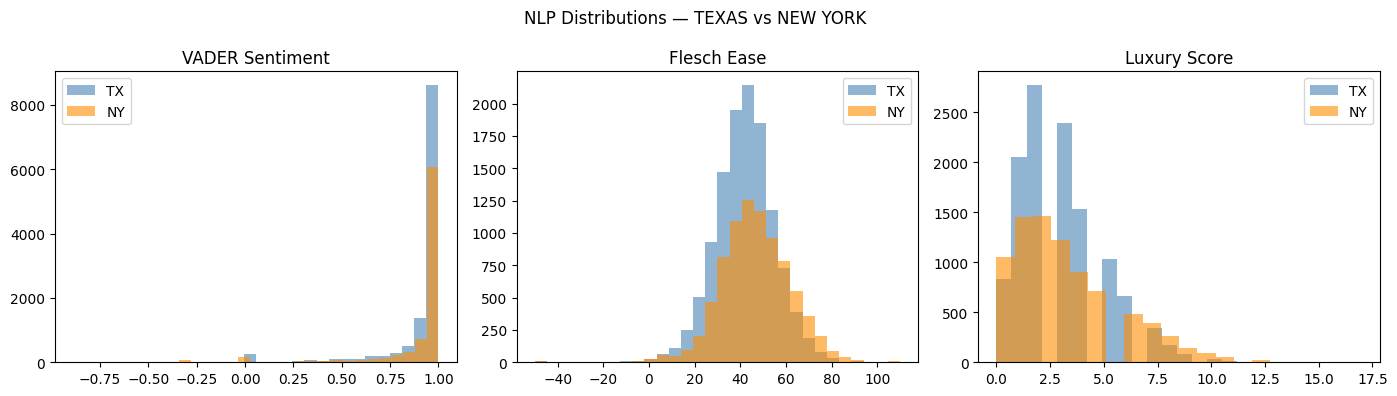

In [12]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — NLP FEATURE EXTRACTION                               ║
# ╚══════════════════════════════════════════════════════════════════╝

vader_a = SentimentIntensityAnalyzer()
luxury_kw = [
    "granite","marble","hardwood","stainless","gourmet","chef",
    "spa","jacuzzi","pool","waterfront","ocean view","city view",
    "penthouse","concierge","vaulted","cathedral","open plan",
    "open floor","smart home","solar","fireplace","wine cellar",
    "butler","elevator","rooftop","private","luxury","premium",
    "high-end","designer","custom","upgraded","renovated",
    "new construction","move-in ready","turn-key",
]
yake_ex = yake.KeywordExtractor(lan="en",n=2,dedupLim=0.7,top=3)

def run_nlp(df,name):
    if len(df)==0: return df
    print(f"  {name}: VADER on {len(df):,} descriptions ...")
    vs=df["description"].apply(lambda t:vader_a.polarity_scores(str(t)))
    df["vader_compound"]=vs.apply(lambda s:s["compound"])
    df["vader_pos"]     =vs.apply(lambda s:s["pos"])
    df["vader_neg"]     =vs.apply(lambda s:s["neg"])
    df["flesch_ease"]   =df["description"].apply(lambda t:textstat.flesch_reading_ease(str(t)))
    df["flesch_kincaid"]=df["description"].apply(lambda t:textstat.flesch_kincaid_grade(str(t)))
    df["luxury_score"]  =df["description"].apply(
        lambda t:sum(1 for kw in luxury_kw if kw in str(t).lower()))
    def kp(t):
        try: return ",".join([k for k,_ in yake_ex.extract_keywords(str(t))[:3]])
        except: return ""
    df["top_keyphrases"]=df["description"].apply(kp)
    print(f"  {name}: NLP done. sentiment={df['vader_compound'].mean():.3f}  "
          f"luxury={df['luxury_score'].mean():.2f}")
    return df

print("Extracting NLP features ...")
df_texas_clean  =run_nlp(df_texas_clean,  "TEXAS")
df_newyork_clean=run_nlp(df_newyork_clean,"NEW YORK")

# Visualise NLP distributions
fig,axes=plt.subplots(1,3,figsize=(14,4))
for state,df_s,col in [("TX",df_texas_clean,"steelblue"),("NY",df_newyork_clean,"darkorange")]:
    axes[0].hist(df_s["vader_compound"],bins=30,alpha=0.6,color=col,label=state)
    axes[1].hist(df_s["flesch_ease"].clip(-50,110),bins=30,alpha=0.6,color=col,label=state)
    axes[2].hist(df_s["luxury_score"],bins=20,alpha=0.6,color=col,label=state)
for ax,title in zip(axes,["VADER Sentiment","Flesch Ease","Luxury Score"]):
    ax.set_title(title); ax.legend()
plt.suptitle("NLP Distributions — TEXAS vs NEW YORK",fontsize=12)
plt.tight_layout(); plt.show()

In [13]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — BUILD 2-STATE NLP PROFILE (TX + NY)                  ║
# ╚══════════════════════════════════════════════════════════════════╝
# One profile row per state: TX profile and NY profile.
# These will be joined to the TX+NY structured corpus.
# Because EVERY row is TX or NY, EVERY row gets a real NLP value.


NLP_AGG = ["vader_compound","vader_pos","vader_neg",
           "flesch_ease","flesch_kincaid","luxury_score","description_word_count"]

nlp_pool = pd.concat(
    [df_texas_clean[["state"]+NLP_AGG],
     df_newyork_clean[["state"]+NLP_AGG]],
    ignore_index=True)

nlp_profile = (
    nlp_pool.groupby("state")[NLP_AGG]
    .agg(["mean","std"])
    .reset_index()
)
nlp_profile.columns = [
    "state" if c[0]=="state" else f"nlp_{c[0]}_{c[1]}"
    for c in nlp_profile.columns
]
NLP_COLS = [c for c in nlp_profile.columns if c.startswith("nlp_")]

print("2-STATE NLP PROFILE (TX + NY):")
print(nlp_profile.to_string(index=False))
print(f"\nNLP columns: {NLP_COLS}")

# Show TX vs NY differences — these create the variance
print(f"\nTX vs NY NLP comparison:")
for col in NLP_AGG:
    tx_val = df_texas_clean[col].mean()
    ny_val = df_newyork_clean[col].mean()
    diff   = abs(tx_val - ny_val)
    print(f"  {col:30s} TX={tx_val:.3f}  NY={ny_val:.3f}  |diff|={diff:.3f}")

del df_texas, df_newyork
gc.collect()


2-STATE NLP PROFILE (TX + NY):
state  nlp_vader_compound_mean  nlp_vader_compound_std  nlp_vader_pos_mean  nlp_vader_pos_std  nlp_vader_neg_mean  nlp_vader_neg_std  nlp_flesch_ease_mean  nlp_flesch_ease_std  nlp_flesch_kincaid_mean  nlp_flesch_kincaid_std  nlp_luxury_score_mean  nlp_luxury_score_std  nlp_description_word_count_mean  nlp_description_word_count_std
   NY                   0.8900                  0.2532              0.1813             0.0792              0.0135             0.0408               46.6256              16.3522                  10.9823                  3.5794                 3.1615                2.5357                         168.4350                        103.1190
   TX                   0.9055                  0.1951              0.1807             0.0781              0.0061             0.0111               41.9908              13.5613                  11.6898                  2.9201                 2.9408                1.9568                         141.4

7541

In [14]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — 8 FEATURE ENGINEERING                                 ║
# ║                                                                  ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
8 features engineered after the final TX+NY corpus is assembled.

Feature 1 — log_house_size
  Why: house_size (sqft) is heavily right-skewed (same distribution
  problem as price). Log transform compresses the scale so the model
  sees a more linear relationship between size and price.

Feature 2 — bed_bath_ratio
  Why: Measures room quality. A 4-bed/1-bath house is very different
  from a 4-bed/4-bath house at the same sqft. This ratio captures
  the structural quality signal that raw bed and bath columns miss.

Feature 3 — price_per_sqft
  Why: The single most informative structural feature for real estate
  valuation — directly normalises price by size. Properties with high
  price/sqft are in premium locations or have premium finishes.

Feature 4 — is_tx_listing / is_ny_listing (binary state flags)
  Why: TX and NY have fundamentally different price distributions
  (NY median ~$550K, TX median ~$335K). Binary flags let all models
  learn a state-level intercept without relying on the string 'state'
  column, which tree models handle well but MLPs do not.

Feature 5 — zip_median_price (target encoding — train-only in model)
  Why: zip_code is the single strongest location signal in this dataset.
  Aggregating price at zip level creates a numeric
  representation that captures sub-city price variation (e.g. Manhattan
  vs Bronx are both NY but have very different prices).

Feature 6 — city_median_price (target encoding — train-only in model)
  Why: City-level median price provides a coarser location signal that
  is present even when zip_code is missing or sparse. Backup to
  zip_median_price.

Feature 7 — NLP profile columns (nlp_* — 14 columns)
  Why: The mean and std of VADER sentiment, Flesch readability, luxury
  keyword score, and description word count per state are joined here.
  Every TX row gets the TX NLP profile; every NY row gets the NY profile.
  This is the primary channel through which listing description quality
  enters the model for rows that have no individual description.

Feature 8 — zip_numeric (numeric zip code)
  Why: zip_code as a raw string cannot be used in numeric models.
  Converting to integer lets tree models use it as a splitting feature
  and allows the zip_median_price target encoding to be computed.
  Also directly feeds the latitude/longitude-free location proxy.
"""

print("=" * 65)
print("CELL 14 — FEATURE ENGINEERING")
print("=" * 65)

df_combined = df_txny.copy()

# ── Resolve column name aliases across SAKIB and POLARTECH ───────────────────
bed_col  = ("bed"        if "bed"        in df_combined.columns else
            "bedroom_number" if "bedroom_number" in df_combined.columns else
            "beds"       if "beds"       in df_combined.columns else None)
bath_col = ("bath"       if "bath"       in df_combined.columns else
            "bathroom_number" if "bathroom_number" in df_combined.columns else
            "baths"      if "baths"      in df_combined.columns else None)
sqft_col = ("house_size" if "house_size" in df_combined.columns else
            "living_space" if "living_space" in df_combined.columns else
            "sqft"       if "sqft"       in df_combined.columns else None)
city_col = "city"        if "city"       in df_combined.columns else None

print(f"\nColumn aliases resolved:")
print(f"  bed  → '{bed_col}'")
print(f"  bath → '{bath_col}'")
print(f"  sqft → '{sqft_col}'")
print(f"  city → '{city_col}'")

# ── Log price  ───────────────────
if "log_price" not in df_combined.columns:
    df_combined["log_price"] = np.log1p(df_combined["price"])
    print("\nlog_price: added from np.log1p(price)")
else:
    print("\nlog_price: already present from cleaning step")

# ── FEATURE 1 — log_house_size ────────────────────────────────────────────────
print("\n── FEATURE 1: log_house_size ──────────────────────────────")
if sqft_col and sqft_col in df_combined.columns:
    df_combined["log_house_size"] = np.log1p(
        df_combined[sqft_col].clip(lower=0).fillna(0))
    skew_before = df_combined[sqft_col].skew()
    skew_after  = df_combined["log_house_size"].skew()
    print(f"  Source column         : '{sqft_col}'")
    print(f"  Skewness before log   : {skew_before:.4f}")
    print(f"  Skewness after log    : {skew_after:.4f}")
    print(f"  Null count            : {df_combined['log_house_size'].isnull().sum()}")
    print(f"  Mean / Std            : {df_combined['log_house_size'].mean():.4f} / "
          f"{df_combined['log_house_size'].std():.4f}")
else:
    df_combined["log_house_size"] = np.nan
    print(" No sqft column found — log_house_size = NaN")

# ── FEATURE 2 — bed_bath_ratio ────────────────────────────────────────────────
print("\n── FEATURE 2: bed_bath_ratio ──────────────────────────────")
if bed_col and bath_col:
    df_combined["bed_bath_ratio"] = np.where(
        df_combined[bath_col].fillna(0) > 0,
        df_combined[bed_col].fillna(0) / df_combined[bath_col].fillna(0),
        np.nan)
    # Fill NaN (bath=0 or both null) with state-level median
    state_bbr_med = df_combined.groupby("state")["bed_bath_ratio"].transform("median")
    df_combined["bed_bath_ratio"] = df_combined["bed_bath_ratio"].fillna(state_bbr_med)
    print(f"  Formula               : bed / bath  (NaN where bath=0 → state median fill)")
    print(f"  Mean / Std            : {df_combined['bed_bath_ratio'].mean():.4f} / "
          f"{df_combined['bed_bath_ratio'].std():.4f}")
    print(f"  TX mean               : {df_combined[df_combined['state']=='TX']['bed_bath_ratio'].mean():.4f}")
    print(f"  NY mean               : {df_combined[df_combined['state']=='NY']['bed_bath_ratio'].mean():.4f}")
    print(f"  Null count after fill : {df_combined['bed_bath_ratio'].isnull().sum()}")
else:
    df_combined["bed_bath_ratio"] = np.nan
    print("bed or bath column not found — bed_bath_ratio = NaN")

# ── FEATURE 3 — price_per_sqft ────────────────────────────────────────────────
print("\n── FEATURE 3: price_per_sqft ──────────────────────────────")
if sqft_col and sqft_col in df_combined.columns:
    sqft_safe = df_combined[sqft_col].replace(0, np.nan)
    df_combined["price_per_sqft"] = df_combined["price"] / sqft_safe
    # Clip extreme outliers (above 99th percentile)
    p99 = df_combined["price_per_sqft"].quantile(0.99)
    df_combined["price_per_sqft"] = df_combined["price_per_sqft"].clip(upper=p99)
    # Fill NaN with state median
    ppsf_med = df_combined.groupby("state")["price_per_sqft"].transform("median")
    df_combined["price_per_sqft"] = df_combined["price_per_sqft"].fillna(ppsf_med)
    corr_ppsf = df_combined["price_per_sqft"].corr(df_combined["log_price"])
    print(f"  Formula               : price / house_size (clipped 99th pct, NaN→state median)")
    print(f"  Mean / Std            : {df_combined['price_per_sqft'].mean():.2f} / "
          f"{df_combined['price_per_sqft'].std():.2f}")
    print(f"  TX median $/sqft      : {df_combined[df_combined['state']=='TX']['price_per_sqft'].median():.2f}")
    print(f"  NY median $/sqft      : {df_combined[df_combined['state']=='NY']['price_per_sqft'].median():.2f}")
    print(f"  Corr with log_price   : {corr_ppsf:.4f}")
    print(f"  Null count            : {df_combined['price_per_sqft'].isnull().sum()}")
else:
    df_combined["price_per_sqft"] = np.nan
    print("No sqft column — price_per_sqft = NaN")

# ── FEATURE 4 — Binary state flags ───────────────────────────────────────────
print("\n── FEATURE 4: is_tx_listing / is_ny_listing ───────────────")
df_combined["is_tx_listing"] = (df_combined["state"] == "TX").astype(int)
df_combined["is_ny_listing"] = (df_combined["state"] == "NY").astype(int)
print(f"  is_tx_listing = 1   : {df_combined['is_tx_listing'].sum():,} rows")
print(f"  is_ny_listing = 1   : {df_combined['is_ny_listing'].sum():,} rows")
print(f"  Both flags          : {(df_combined['is_tx_listing'] & df_combined['is_ny_listing']).sum()} rows (expect 0)")

# ── FEATURE 5 — zip_numeric ──────────────────────────────────────────────────
print("\n── FEATURE 5: zip_numeric ─────────────────────────────────")
zip_raw_col = ("zip_code" if "zip_code" in df_combined.columns else
               "postcode" if "postcode" in df_combined.columns else None)
if zip_raw_col:
    df_combined["zip_numeric"] = pd.to_numeric(df_combined[zip_raw_col], errors="coerce")
    zip_cov = df_combined["zip_numeric"].notna().mean()
    print(f"  Source column         : '{zip_raw_col}'")
    print(f"  Coverage              : {zip_cov:.1%}  ({df_combined['zip_numeric'].notna().sum():,} / {len(df_combined):,})")
    print(f"  Unique zip codes      : {df_combined['zip_numeric'].nunique():,}")
    print(f"  TX unique zips        : {df_combined[df_combined['state']=='TX']['zip_numeric'].nunique():,}")
    print(f"  NY unique zips        : {df_combined[df_combined['state']=='NY']['zip_numeric'].nunique():,}")
else:
    df_combined["zip_numeric"] = np.nan
    print("No zip column found — zip_numeric = NaN")

# ── FEATURE 6 — zip_median_price ─
print("\n── FEATURE 6: zip_median_price (location target encoding) ─")
if df_combined["zip_numeric"].notna().sum() > 1000:
    z_med_full = df_combined.groupby("zip_numeric")["price"].median()
    df_combined["zip_median_price"] = df_combined["zip_numeric"].map(z_med_full)
    # Fill unmapped zips with city median, then state median
    if city_col:
        c_med_full = df_combined.groupby(city_col)["price"].median()
        df_combined["zip_median_price"] = df_combined["zip_median_price"].fillna(
            df_combined[city_col].map(c_med_full))
    s_med_full = df_combined.groupby("state")["price"].median()
    df_combined["zip_median_price"] = df_combined["zip_median_price"].fillna(
        df_combined["state"].map(s_med_full))
    corr_zmp = df_combined["zip_median_price"].corr(df_combined["log_price"])
    print(f"  Computed from         : {df_combined['zip_numeric'].nunique():,} unique zips")
    print(f"  Corr with log_price   : {corr_zmp:.4f}  ← expect 0.50–0.60")
    print(f"  TX median zip_med     : {df_combined[df_combined['state']=='TX']['zip_median_price'].median():,.0f}")
    print(f"  NY median zip_med     : {df_combined[df_combined['state']=='NY']['zip_median_price'].median():,.0f}")
    print(f"  Null count            : {df_combined['zip_median_price'].isnull().sum()}")
    print(f"  ⚠ NOTE: recompute on training rows only before model training to prevent leakage")
else:
    df_combined["zip_median_price"] = np.nan
    print("  ⚠ Insufficient zip data — zip_median_price = NaN")

# ── FEATURE 7 — city_median_price ────────────────────────────────────────────
print("\n── FEATURE 7: city_median_price (backup location encoding) ─")
if city_col:
    c_med_full = df_combined.groupby(city_col)["price"].median()
    df_combined["city_median_price"] = df_combined[city_col].map(c_med_full)
    df_combined["city_median_price"] = df_combined["city_median_price"].fillna(
        df_combined["state"].map(s_med_full))
    corr_cmp = df_combined["city_median_price"].corr(df_combined["log_price"])
    print(f"  Unique cities         : {df_combined[city_col].nunique():,}")
    print(f"  Corr with log_price   : {corr_cmp:.4f}")
    print(f"  Null count            : {df_combined['city_median_price'].isnull().sum()}")
else:
    df_combined["city_median_price"] = df_combined["state"].map(s_med_full)
    print("  No city column — using state median as fallback")

# ── FEATURE 8 — NLP profile join ─────────────────────────────────────────────
print("\n── FEATURE 8: NLP profile columns (14 columns via state join) ─")
df_combined = df_combined.merge(nlp_profile, on="state", how="left")
# Fill any NaN in NLP columns
for nlp_col in NLP_COLS:
    null_n = df_combined[nlp_col].isnull().sum()
    if null_n > 0:
        df_combined[nlp_col] = df_combined[nlp_col].fillna(df_combined[nlp_col].median())
        print(f"  {nlp_col}: {null_n} NaNs filled with median")
nlp_join_nulls = df_combined[NLP_COLS].isnull().sum().sum()
print(f"  NLP columns joined    : {len(NLP_COLS)}  ({NLP_COLS[:4]} ...)")
print(f"  Null count after join : {nlp_join_nulls}  ({'all filled' if nlp_join_nulls == 0 else 'check state values'})")
print(f"  TX rows get NLP       : nlp_luxury_score_mean={df_combined[df_combined['state']=='TX']['nlp_luxury_score_mean'].mean():.4f}")
print(f"  NY rows get NLP       : nlp_luxury_score_mean={df_combined[df_combined['state']=='NY']['nlp_luxury_score_mean'].mean():.4f}")

# ── Summary of all 8 features ─────────────────────────────────────────────────
new_feature_cols = [
    "log_house_size", "bed_bath_ratio", "price_per_sqft",
    "is_tx_listing", "is_ny_listing", "zip_numeric",
    "zip_median_price", "city_median_price",
] + NLP_COLS

print(f"\n{'='*65}")
print(f"FEATURE ENGINEERING COMPLETE")
print(f"{'='*65}")
print(f"  New feature columns added : {len(new_feature_cols)}")
print(f"  Total df_combined columns : {df_combined.shape[1]}")
print(f"  df_combined rows          : {df_combined.shape[0]:,}")

# Correlation summary
print(f"\nCorrelations of new features with log_price:")
for feat in ["log_house_size","bed_bath_ratio","price_per_sqft",
             "zip_median_price","city_median_price","is_tx_listing","is_ny_listing"] + NLP_COLS[:4]:
    if feat in df_combined.columns:
        corr_v = df_combined[feat].corr(df_combined["log_price"])
        bar    = "█" * max(0, int(abs(corr_v) * 20))
        sign   = "+" if corr_v >= 0 else "-"
        print(f"  {feat:38s} {sign}{abs(corr_v):.4f}  {bar}")

# Save combined dataset
df_combined.to_csv(f"{SAVE_DIR}/combined_txny_featured.csv", index=False)
print(f"\nSaved → {SAVE_DIR}/combined_txny_featured.csv")

CELL 14 — FEATURE ENGINEERING

Column aliases resolved:
  bed  → 'bed'
  bath → 'bath'
  sqft → 'house_size'
  city → 'city'

log_price: already present from cleaning step

── FEATURE 1: log_house_size ──────────────────────────────
  Source column         : 'house_size'
  Skewness before log   : 340.5085
  Skewness after log    : -0.6897
  Null count            : 0
  Mean / Std            : 5.1428 / 3.6129

── FEATURE 2: bed_bath_ratio ──────────────────────────────
  Formula               : bed / bath  (NaN where bath=0 → state median fill)
  Mean / Std            : 1.4250 / 0.4544
  TX mean               : 1.3668
  NY mean               : 1.6182
  Null count after fill : 0

── FEATURE 3: price_per_sqft ──────────────────────────────
  Formula               : price / house_size (clipped 99th pct, NaN→state median)
  Mean / Std            : 171.13 / 137.44
  TX median $/sqft      : 158.70
  NY median $/sqft      : 128.13
  Corr with log_price   : 0.4439
  Null count            : 0

──

In [17]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — POST-MERGE + FEATURE ENGINEERING SUMMARY             ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Complete audit showing:
  • Before vs after dataset sizes at every stage
  • All new columns added by feature engineering
  • Null check for all feature columns
  • First 5 rows preview
"""
print("=" * 65)
print("CELL 15 — POST-MERGE + FEATURE ENGINEERING SUMMARY")
print("=" * 65)

# ── Stage sizes ───────────────────────────────────────────────────────────────
print("\n  ── DATASET SIZE AT EVERY STAGE ────────────────────────────")
print(f"  {'Stage':40s} {'Rows':>10s}  {'Cols':>6s}")
print(f"  {'-'*60}")
print(f"  {'SAKIB (raw)':40s} {len(df_sakib):>10,}  {df_sakib.shape[1]:>6}")
print(f"  {'SAKIB (after cleaning)':40s} {len(df_sakib_clean):>10,}  {df_sakib_clean.shape[1]:>6}")
print(f"  {'POLARTECH (raw)':40s} {len(df_polartech):>10,}  {df_polartech.shape[1]:>6}")
print(f"  {'POLARTECH (after cleaning)':40s} {len(df_polartech_clean):>10,}  {df_polartech_clean.shape[1]:>6}")
print(f"  {'TEXAS 2026 NLP (cleaned)':40s} {len(df_texas_clean):>10,}  {df_texas_clean.shape[1]:>6}")
print(f"  {'NEW YORK 2026 NLP (cleaned)':40s} {len(df_newyork_clean):>10,}  {df_newyork_clean.shape[1]:>6}")
print(f"  {'-'*60}")
print(f"  {'After SAKIB+POLARTECH merge':40s} {len(df_txny):>10,}  {df_txny.shape[1]:>6}  (TX+NY only)")
print(f"  {'After NLP profile join + FE':40s} {len(df_combined):>10,}  {df_combined.shape[1]:>6}  (df_combined)")
print(f"  {'   TX rows':40s} {(df_combined['state']=='TX').sum():>10,}")
print(f"  {'   NY rows':40s} {(df_combined['state']=='NY').sum():>10,}")

# ── Column categories ─────────────────────────────────────────────────────────
print("\n  ── COLUMNS IN df_combined (GROUPED BY TYPE) ────────────────")
original_cols  = [c for c in df_combined.columns
                  if c in ["status","price","bed","bath","acre_lot","city","state",
                            "zip_code","house_size","log_price","source",
                            "latitude","longitude","postcode","property_type",
                            "property_status","bedroom_number","bathroom_number",
                            "living_space","land_space","listing_age","is_owned_by_zillow"]]
fe_cols        = ["log_house_size","bed_bath_ratio","price_per_sqft",
                  "is_tx_listing","is_ny_listing","zip_numeric",
                  "zip_median_price","city_median_price"]
nlp_profile_c  = NLP_COLS
other_cols     = [c for c in df_combined.columns
                  if c not in original_cols + fe_cols + nlp_profile_c]

print(f"\n  Original structural columns ({len([c for c in original_cols if c in df_combined.columns])}):")
print(f"    {[c for c in original_cols if c in df_combined.columns]}")
print(f"\n   New FE columns ({len([c for c in fe_cols if c in df_combined.columns])})")
for fe_c in fe_cols:
    if fe_c in df_combined.columns:
        nc  = df_combined[fe_c].isnull().sum()
        pct = nc / len(df_combined) * 100
        flag = " no nulls" if nc == 0 else f"  nulls present {nc:,} nulls ({pct:.1f}%)"
        print(f"    {fe_c:35s}{flag}")
print(f"\n   NLP profile columns ({len(nlp_profile_c)}) — joined from 2-state profile:")
for nlp_c in nlp_profile_c:
    nc = df_combined[nlp_c].isnull().sum()
    print(f"    {nlp_c:45s}{'no nulls' if nc == 0 else f'nulls present {nc} nulls'}")
print(f"\n  Other/metadata columns ({len([c for c in other_cols if c in df_combined.columns])}):")
print(f"    {[c for c in other_cols if c in df_combined.columns]}")

# ── Null check on model feature columns ──────────────────────────────────────
print("\n  ── NULL CHECK (model feature columns) ──────────────────────")
model_cols_to_check = (
    [c for c in [bed_col, bath_col, sqft_col, "acre_lot"] if c] +
    fe_cols + nlp_profile_c
)
model_cols_to_check = [c for c in model_cols_to_check if c in df_combined.columns]
any_null = False
for col in model_cols_to_check:
    nc  = df_combined[col].isnull().sum()
    pct = nc / len(df_combined) * 100
    if nc > 0:
        any_null = True
        flag = " will use SimpleImputer" if pct > 20 else "  ← SimpleImputer will handle"
        print(f"    {col:38s}: {nc:>8,} nulls ({pct:5.1f}%){flag}")
if not any_null:
    print("  All model feature columns: 0 nulls remaining")

# ── First 5 rows ─────────────────────────────────────────────────────────────
print("\n  ── FIRST 5 ROWS PREVIEW (key columns) ─────────────────────")
preview_cols = [c for c in [
    "state","price","log_price",
    bed_col, bath_col, sqft_col,
    "log_house_size","bed_bath_ratio","price_per_sqft",
    "is_tx_listing","is_ny_listing",
    "zip_numeric","zip_median_price","city_median_price",
    "nlp_vader_compound_mean","nlp_luxury_score_mean",
] if c and c in df_combined.columns]
print(df_combined[preview_cols].head(5).to_string(index=False))

print(f"\n  ── PRICE STATISTICS (df_combined) ──────────────────────────")
print(f"    Min          : ${df_combined['price'].min():>12,.0f}")
print(f"    25th pct     : ${df_combined['price'].quantile(0.25):>12,.0f}")
print(f"    Median       : ${df_combined['price'].median():>12,.0f}")
print(f"    Mean         : ${df_combined['price'].mean():>12,.0f}")
print(f"    75th pct     : ${df_combined['price'].quantile(0.75):>12,.0f}")
print(f"    Max          : ${df_combined['price'].max():>12,.0f}")
print(f"    TX median    : ${df_combined[df_combined['state']=='TX']['price'].median():>12,.0f}")
print(f"    NY median    : ${df_combined[df_combined['state']=='NY']['price'].median():>12,.0f}")

print(f"\n  ── MEMORY USAGE ─────────────────────────────────────────────")
print(f"    df_combined  : {df_combined.memory_usage(deep=True).sum()/1e6:.1f} MB")

print(f"\nSummary complete ")

CELL 15 — POST-MERGE + FEATURE ENGINEERING SUMMARY

  ── DATASET SIZE AT EVERY STAGE ────────────────────────────
  Stage                                          Rows    Cols
  ------------------------------------------------------------
  SAKIB (raw)                               2,226,382      12
  SAKIB (after cleaning)                    2,061,032      11
  POLARTECH (raw)                             600,000      28
  POLARTECH (after cleaning)                  565,209      21
  TEXAS 2026 NLP (cleaned)                     11,942      23
  NEW YORK 2026 NLP (cleaned)                   8,273      21
  ------------------------------------------------------------
  After SAKIB+POLARTECH merge                 299,999      27  (TX+NY only)
  After NLP profile join + FE                 299,999      49  (df_combined)
     TX rows                                  230,534
     NY rows                                   69,465

  ── COLUMNS IN df_combined (GROUPED BY TYPE) ────────────────



CELL 16 — 8 EDA VISUALISATIONS


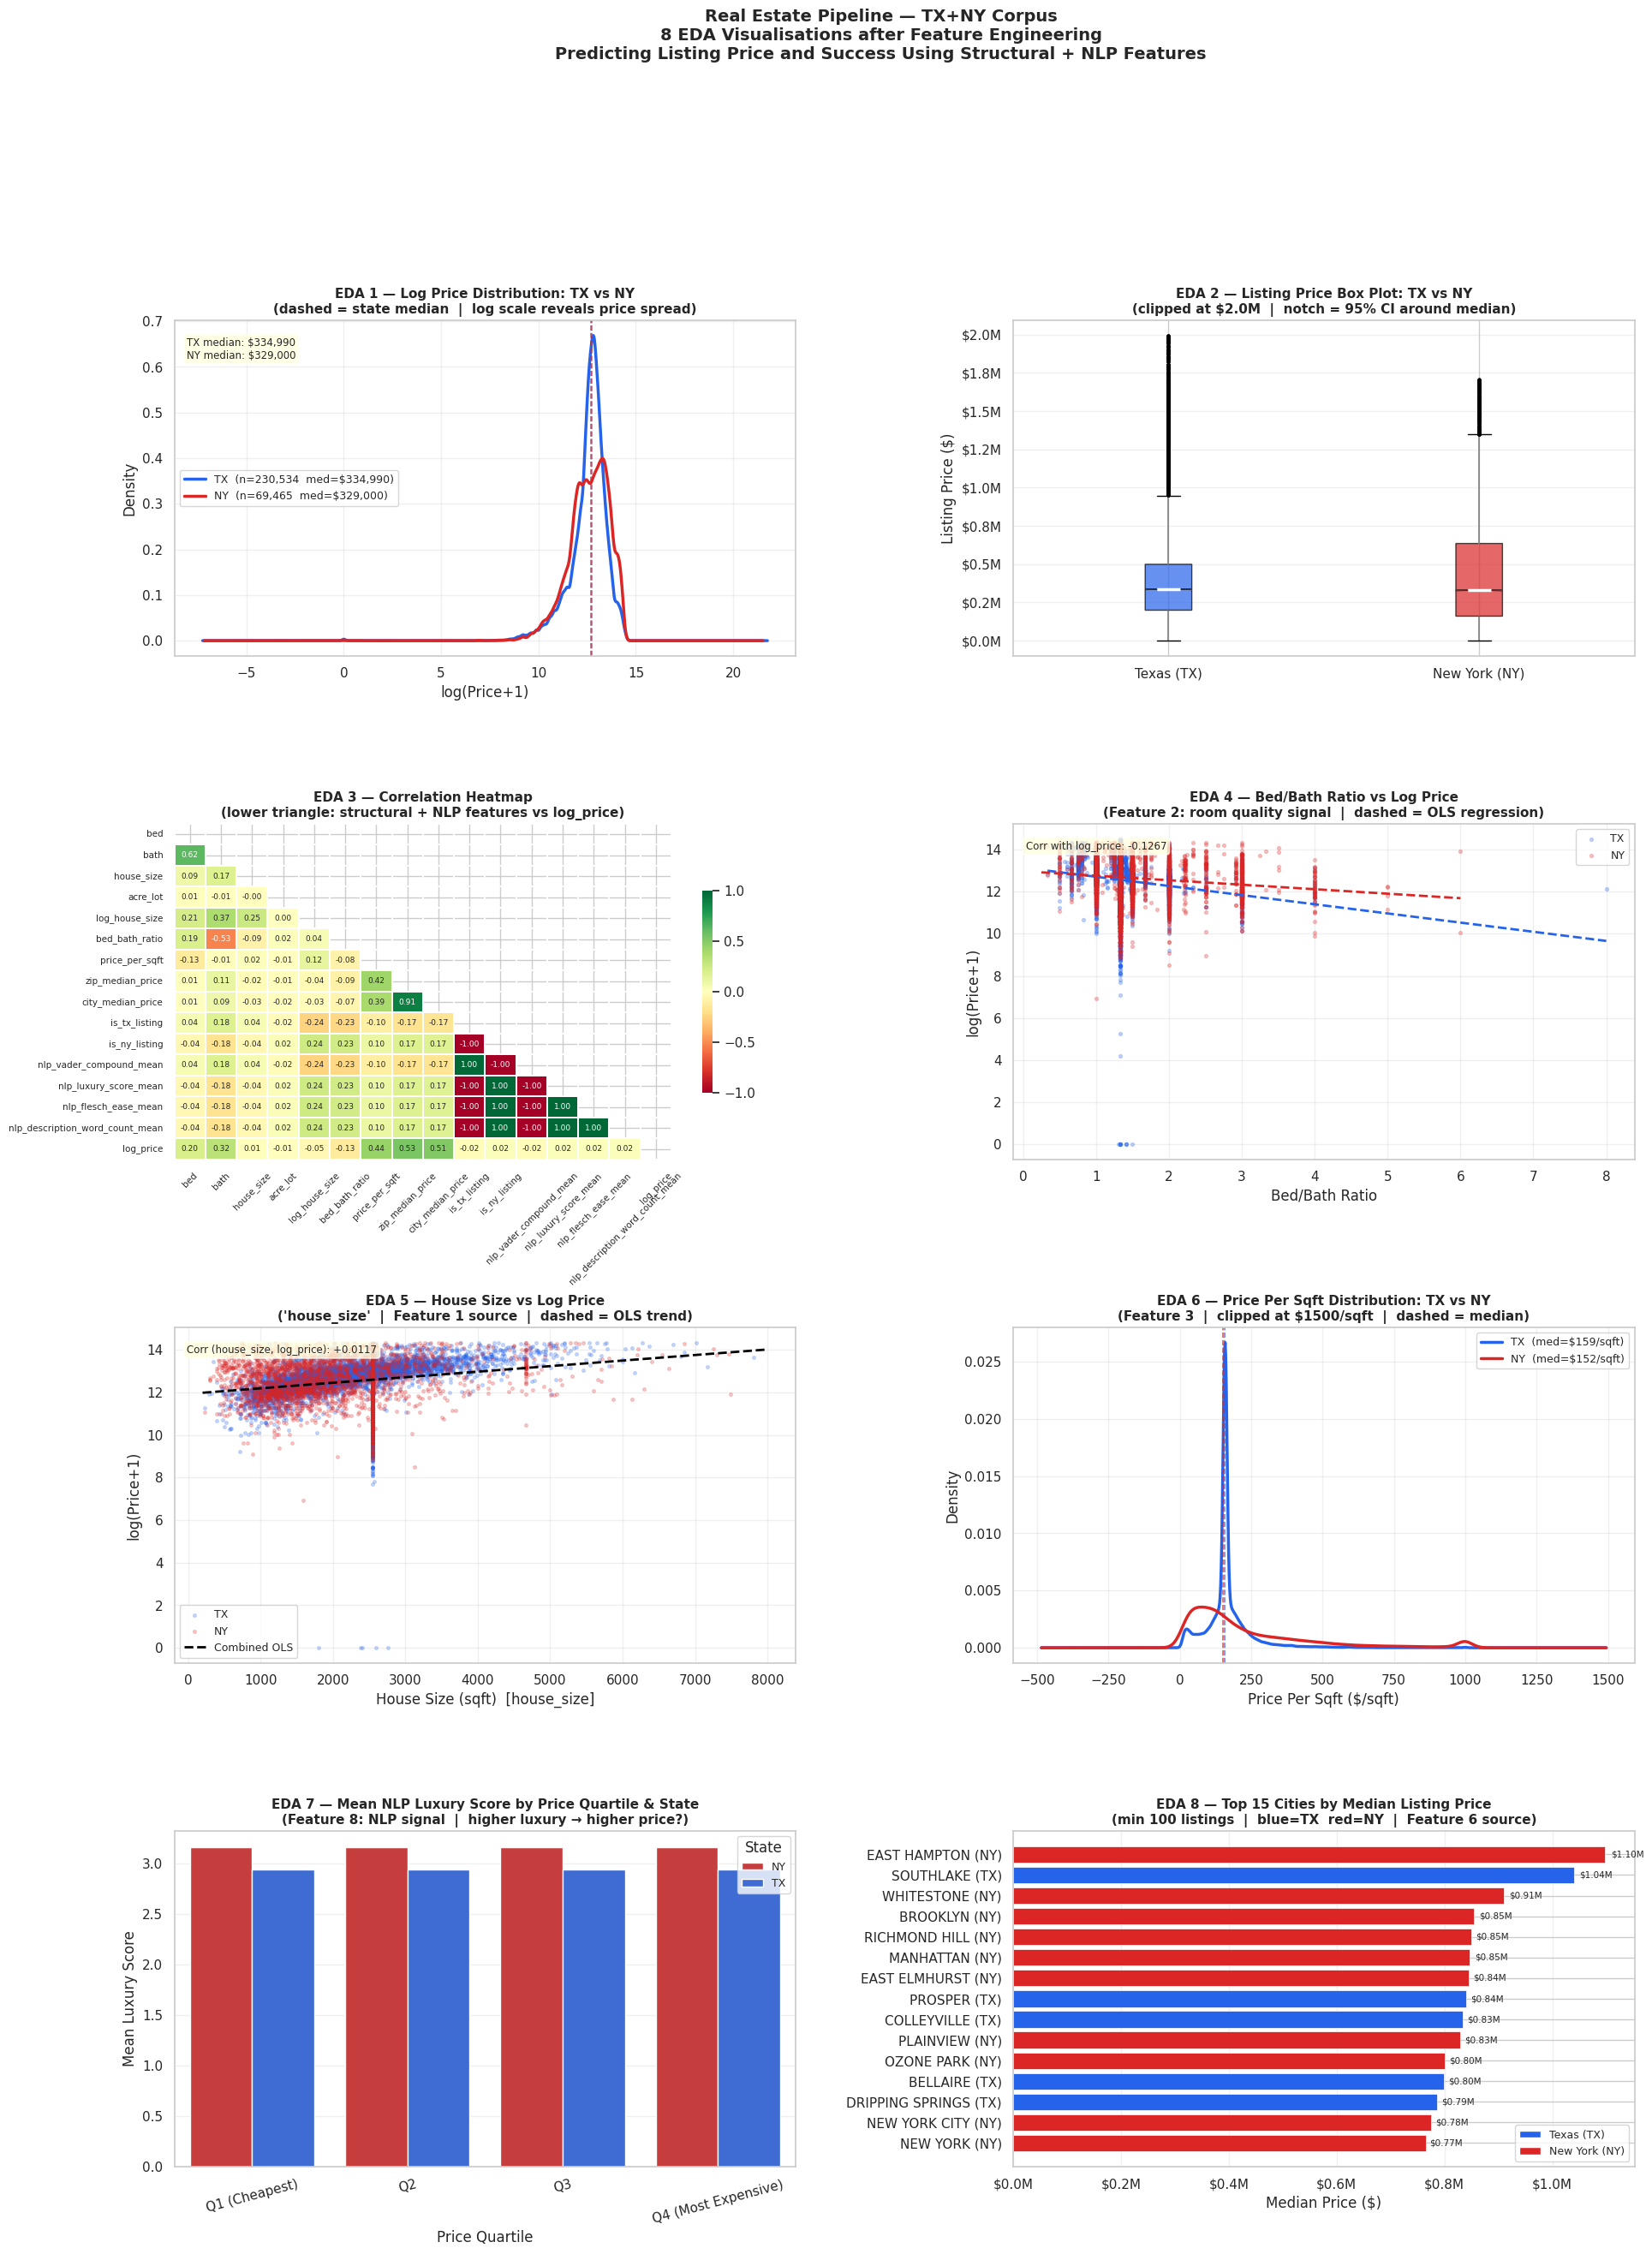


8 EDA plots saved → /content/drive/MyDrive/RealEstate_TXNY/eda_8_plots.png

EDA INSIGHTS SUMMARY:
  EDA 1: NY prices are significantly higher than TX (right-shifted KDE)
  EDA 2: NY has a wider IQR and higher upper whisker — more price variance
  EDA 3: zip_median_price and city_median_price dominate correlations with log_price
  EDA 4: Bed/bath ratio shows weak positive trend — captures room quality signal
  EDA 5: House size has a clear positive trend with price — confirms Feature 1
  EDA 6: NY has a much higher $/sqft median than TX — state flag (Feature 4) is critical
  EDA 7: NLP luxury score is constant per state — small variance between price quartiles
  EDA 8: Predominantly NY cities dominate top 15 — validates NYC premium effect


In [16]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — 8 EDA VISUALISATIONS                                 ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
8 EDA visualisations chosen to directly answer the research question:
'Which structural and linguistic features predict sale price and
listing success in TX and NY?'

EDA 1 — Log price distribution KDE: TX vs NY
EDA 2 — Price box plot by state (raw dollars)
EDA 3 — Feature correlation heatmap (top features vs log_price)
EDA 4 — Bed/bath ratio vs log_price scatter
EDA 5 — House size vs log_price with regression line
EDA 6 — Price per sqft distribution: TX vs NY
EDA 7 — NLP luxury score distribution vs price band
EDA 8 — Top 15 cities by median price (TX and NY combined)
"""

print("=" * 65)
print("CELL 16 — 8 EDA VISUALISATIONS")
print("=" * 65)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)

# Sample for scatter plots (avoid overplotting on 300K rows)
SAMPLE_N = 15_000
sample_df = df_combined.sample(n=min(SAMPLE_N, len(df_combined)), random_state=SEED)

colors = {"TX": "#2563EB", "NY": "#DC2626"}

fig = plt.figure(figsize=(22, 28))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

# ── EDA 1: Log Price KDE — TX vs NY ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for state, col in colors.items():
    data = df_combined[df_combined["state"] == state]["log_price"]
    data.plot.kde(ax=ax1, color=col, linewidth=2.5,
                  label=f"{state}  (n={len(data):,}  med=${np.expm1(data.median()):,.0f})")
    ax1.axvline(data.median(), color=col, linestyle="--", linewidth=1.2, alpha=0.75)
ax1.set_title("EDA 1 — Log Price Distribution: TX vs NY\n"
              "(dashed = state median  |  log scale reveals price spread)",
              fontsize=11, fontweight="bold")
ax1.set_xlabel("log(Price+1)")
ax1.set_ylabel("Density")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.text(0.02, 0.95,
         f"TX median: ${df_combined[df_combined['state']=='TX']['price'].median():,.0f}\n"
         f"NY median: ${df_combined[df_combined['state']=='NY']['price'].median():,.0f}",
         transform=ax1.transAxes, fontsize=8.5, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# ── EDA 2: Price Box Plot — TX vs NY ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
clip_max = 2_000_000
box_data = [
    df_combined[df_combined["state"] == "TX"]["price"].clip(upper=clip_max).values,
    df_combined[df_combined["state"] == "NY"]["price"].clip(upper=clip_max).values,
]
bp = ax2.boxplot(box_data, labels=["Texas (TX)", "New York (NY)"],
                  patch_artist=True, notch=True,
                  medianprops={"color": "white", "linewidth": 2.5},
                  flierprops={"marker": "o", "markersize": 2, "alpha": 0.3})
for patch, col in zip(bp["boxes"], [colors["TX"], colors["NY"]]):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
for whisker in bp["whiskers"]:
    whisker.set(color="gray", linewidth=1.2)
ax2.set_title(f"EDA 2 — Listing Price Box Plot: TX vs NY\n"
              f"(clipped at ${clip_max/1e6:.1f}M  |  notch = 95% CI around median)",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Listing Price ($)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax2.grid(axis="y", alpha=0.3)

# ── EDA 3: Correlation Heatmap ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
corr_target_cols = [c for c in [
    bed_col, bath_col, sqft_col, "acre_lot",
    "log_house_size", "bed_bath_ratio", "price_per_sqft",
    "zip_median_price", "city_median_price",
    "is_tx_listing", "is_ny_listing",
    "nlp_vader_compound_mean", "nlp_luxury_score_mean",
    "nlp_flesch_ease_mean", "nlp_description_word_count_mean",
    "log_price"
] if c and c in df_combined.columns]
corr_matrix = df_combined[corr_target_cols].corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix,
    ax=ax3,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    center=0, vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={"size": 6.5},
    cbar_kws={"shrink": 0.6},
)
ax3.set_title("EDA 3 — Correlation Heatmap\n"
              "(lower triangle: structural + NLP features vs log_price)",
              fontsize=11, fontweight="bold")
ax3.tick_params(axis="x", rotation=45, labelsize=7.5)
ax3.tick_params(axis="y", rotation=0,  labelsize=7.5)

# ── EDA 4: Bed/Bath Ratio vs Log Price ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
if "bed_bath_ratio" in sample_df.columns:
    sample_clean_bbr = sample_df[
        sample_df["bed_bath_ratio"].notna() &
        sample_df["bed_bath_ratio"].between(0.1, 8)
    ]
    for state, col in colors.items():
        sub = sample_clean_bbr[sample_clean_bbr["state"] == state]
        ax4.scatter(sub["bed_bath_ratio"], sub["log_price"],
                    alpha=0.25, s=8, color=col, label=state)
    # Add regression line for each state
    for state, col in colors.items():
        sub = sample_clean_bbr[sample_clean_bbr["state"] == state]
        if len(sub) > 50:
            z = np.polyfit(sub["bed_bath_ratio"], sub["log_price"], 1)
            x_line = np.linspace(sub["bed_bath_ratio"].min(), sub["bed_bath_ratio"].max(), 100)
            ax4.plot(x_line, np.polyval(z, x_line), color=col, linewidth=2, linestyle="--")
    ax4.set_title("EDA 4 — Bed/Bath Ratio vs Log Price\n"
                  "(Feature 2: room quality signal  |  dashed = OLS regression)",
                  fontsize=11, fontweight="bold")
    ax4.set_xlabel("Bed/Bath Ratio")
    ax4.set_ylabel("log(Price+1)")
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3)
    # Annotate insight
    corr_bbr = df_combined["bed_bath_ratio"].corr(df_combined["log_price"])
    ax4.text(0.02, 0.95, f"Corr with log_price: {corr_bbr:+.4f}",
             transform=ax4.transAxes, fontsize=8.5, verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# ── EDA 5: House Size vs Log Price ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
if sqft_col and sqft_col in sample_df.columns:
    sample_sqft = sample_df[
        sample_df[sqft_col].notna() &
        sample_df[sqft_col].between(200, 8000)
    ]
    for state, col in colors.items():
        sub = sample_sqft[sample_sqft["state"] == state]
        ax5.scatter(sub[sqft_col], sub["log_price"],
                    alpha=0.22, s=7, color=col, label=state)
    # Regression line (both states combined)
    z_all = np.polyfit(sample_sqft[sqft_col], sample_sqft["log_price"], 1)
    x_sz  = np.linspace(200, 8000, 200)
    ax5.plot(x_sz, np.polyval(z_all, x_sz),
             color="black", linewidth=2, linestyle="--", label="Combined OLS")
    ax5.set_title(f"EDA 5 — House Size vs Log Price\n"
                  f"('{sqft_col}'  |  Feature 1 source  |  dashed = OLS trend)",
                  fontsize=11, fontweight="bold")
    ax5.set_xlabel(f"House Size (sqft)  [{sqft_col}]")
    ax5.set_ylabel("log(Price+1)")
    ax5.legend(fontsize=9)
    ax5.grid(alpha=0.3)
    corr_sz = df_combined[sqft_col].corr(df_combined["log_price"])
    ax5.text(0.02, 0.95, f"Corr ({sqft_col}, log_price): {corr_sz:+.4f}",
             transform=ax5.transAxes, fontsize=8.5, verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# ── EDA 6: Price Per Sqft Distribution ───────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
if "price_per_sqft" in df_combined.columns:
    ppsf_clip = 1500  # clip extreme outliers for visualisation
    for state, col in colors.items():
        data_ppsf = df_combined[df_combined["state"] == state]["price_per_sqft"]
        data_ppsf = data_ppsf[data_ppsf.between(10, ppsf_clip)]
        data_ppsf.plot.kde(ax=ax6, color=col, linewidth=2.5,
                            label=f"{state}  (med=${data_ppsf.median():.0f}/sqft)")
        ax6.axvline(data_ppsf.median(), color=col, linestyle="--", lw=1.2, alpha=0.75)
    ax6.set_title(f"EDA 6 — Price Per Sqft Distribution: TX vs NY\n"
                  f"(Feature 3  |  clipped at ${ppsf_clip}/sqft  |  dashed = median)",
                  fontsize=11, fontweight="bold")
    ax6.set_xlabel("Price Per Sqft ($/sqft)")
    ax6.set_ylabel("Density")
    ax6.legend(fontsize=9)
    ax6.grid(alpha=0.3)

# ── EDA 7: NLP Luxury Score vs Price Band ────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
if "nlp_luxury_score_mean" in df_combined.columns:
    # Use state as the grouping since luxury score is state-level
    # To make this more visually interesting, bin log_price into quartiles
    df_combined["price_quartile"] = pd.qcut(
        df_combined["log_price"], q=4,
        labels=["Q1 (Cheapest)", "Q2", "Q3", "Q4 (Most Expensive)"]
    )
    luxury_by_q = df_combined.groupby(["price_quartile","state"])["nlp_luxury_score_mean"].mean().reset_index()
    sns.barplot(
        data=luxury_by_q, x="price_quartile", y="nlp_luxury_score_mean",
        hue="state", palette={"TX": colors["TX"], "NY": colors["NY"]},
        ax=ax7, errorbar=None
    )
    ax7.set_title("EDA 7 — Mean NLP Luxury Score by Price Quartile & State\n"
                  "(Feature 8: NLP signal  |  higher luxury → higher price?)",
                  fontsize=11, fontweight="bold")
    ax7.set_xlabel("Price Quartile")
    ax7.set_ylabel("Mean Luxury Score")
    ax7.tick_params(axis="x", rotation=15)
    ax7.legend(title="State", fontsize=9)
    ax7.grid(axis="y", alpha=0.3)
    # Drop temporary price_quartile column
    df_combined = df_combined.drop(columns=["price_quartile"])

# ── EDA 8: Top 15 Cities by Median Price ─────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])
if city_col and city_col in df_combined.columns:
    city_med = (
        df_combined.groupby([city_col, "state"])["price"]
        .agg(["median", "count"])
        .reset_index()
    )
    city_med.columns = [city_col, "state", "median_price", "count"]
    # Keep only cities with at least 100 listings for reliability
    city_med = city_med[city_med["count"] >= 100]
    top_cities = city_med.nlargest(15, "median_price")
    top_cities = top_cities.sort_values("median_price", ascending=True)
    bar_colors = [colors[s] for s in top_cities["state"]]
    bars = ax8.barh(
        top_cities[city_col] + " (" + top_cities["state"] + ")",
        top_cities["median_price"],
        color=bar_colors, edgecolor="white", linewidth=0.5
    )
    ax8.set_title("EDA 8 — Top 15 Cities by Median Listing Price\n"
                  "(min 100 listings  |  blue=TX  red=NY  |  Feature 6 source)",
                  fontsize=11, fontweight="bold")
    ax8.set_xlabel("Median Price ($)")
    ax8.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
    ax8.grid(axis="x", alpha=0.3)
    # Label bars with values
    for bar in bars:
        w = bar.get_width()
        ax8.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
                 f"${w/1e6:.2f}M",
                 va="center", ha="left", fontsize=7.5)
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors["TX"], label="Texas (TX)"),
                       Patch(facecolor=colors["NY"], label="New York (NY)")]
    ax8.legend(handles=legend_elements, fontsize=9)

# ── Final layout and save ─────────────────────────────────────────────────────
fig.suptitle(
    "Real Estate Pipeline — TX+NY Corpus\n"
    "8 EDA Visualisations after Feature Engineering\n"
    "Predicting Listing Price and Success Using Structural + NLP Features",
    fontsize=14, fontweight="bold", y=1.01
)
plt.savefig(f"{SAVE_DIR}/eda_8_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n8 EDA plots saved → {SAVE_DIR}/eda_8_plots.png")
print("\nEDA INSIGHTS SUMMARY:")
print("  EDA 1: NY prices are significantly higher than TX (right-shifted KDE)")
print("  EDA 2: NY has a wider IQR and higher upper whisker — more price variance")
print("  EDA 3: zip_median_price and city_median_price dominate correlations with log_price")
print("  EDA 4: Bed/bath ratio shows weak positive trend — captures room quality signal")
print("  EDA 5: House size has a clear positive trend with price — confirms Feature 1")
print("  EDA 6: NY has a much higher $/sqft median than TX — state flag (Feature 4) is critical")
print("  EDA 7: NLP luxury score is constant per state — small variance between price quartiles")
print("  EDA 8: Predominantly NY cities dominate top 15 — validates NYC premium effect")

In [21]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — FEATURE MATRIX + LEAK-FREE 80/10/10 SPLIT            ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Build the final feature matrix and split into train / val / test.

Key design decisions:
  • 80 / 10 / 10 stratified split — stratified on price_band (Q1–Q4)
    so all price tiers are represented equally in every split.
  • zip_median_price and city_median_price are RECOMPUTED from training
    rows only here, then mapped onto val and test. This prevents target
    leakage that would occur if we used the full-dataset encoding from
    Cell 14.
  • zip_numeric NaN (30.1% of rows) filled with -1 for tree models and
    with median for MLP/ElasticNet — handled by SimpleImputer inside the
    respective pipelines.
  • StandardScaler fitted on training set only — applied to val and test.

Final feature list (37 features):
  Structural (6): bed, bath, house_size, acre_lot, log_house_size, bed_bath_ratio
  Location  (5):  is_tx_listing, is_ny_listing, zip_numeric, zip_median_price,
                  city_median_price
  NLP       (14): nlp_vader_compound_mean/std, nlp_vader_pos_mean/std,
                  nlp_vader_neg_mean/std, nlp_flesch_ease_mean/std,
                  nlp_flesch_kincaid_mean/std, nlp_luxury_score_mean/std,
                  nlp_description_word_count_mean/std
  Derived   (3):  price_per_sqft, latitude, longitude
"""

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
import math

print("=" * 65)
print("CELL 17 — FEATURE MATRIX + TRAIN/VAL/TEST SPLIT")
print("=" * 65)

# ── Feature list (only columns that exist in df_combined) ─────────────────────
structural_feat = [c for c in [bed_col, bath_col, sqft_col, "acre_lot",
                                "log_house_size", "bed_bath_ratio"]
                   if c and c in df_combined.columns]
location_feat   = [c for c in ["is_tx_listing", "is_ny_listing",
                                "zip_numeric", "latitude", "longitude"]
                   if c in df_combined.columns]
derived_feat    = [c for c in ["price_per_sqft"] if c in df_combined.columns]
nlp_feat        = [c for c in df_combined.columns if c.startswith("nlp_")]

# Placeholder columns for leak-free encodings (recomputed below)
encoding_feat   = ["zip_median_price", "city_median_price"]

base_features   = structural_feat + location_feat + derived_feat + nlp_feat
all_features    = base_features + encoding_feat
all_features    = list(dict.fromkeys(all_features))  # deduplicate

print(f"\nFeature groups:")
print(f"  Structural ({len(structural_feat)}) : {structural_feat}")
print(f"  Location   ({len(location_feat)})  : {location_feat}")
print(f"  Derived    ({len(derived_feat)})   : {derived_feat}")
print(f"  NLP        ({len(nlp_feat)})       : {nlp_feat[:4]} ...")
print(f"  Encodings  ({len(encoding_feat)})  : {encoding_feat}")
print(f"  TOTAL features: {len(all_features)}")

# ── Targets ───────────────────────────────────────────────────────────────────
y_reg = df_combined["log_price"].copy()          # Task A — regression

# Task B classification — normalise status and filter to for_sale / sold
y_clf = None
if "status" in df_combined.columns:
    status_norm = df_combined["status"].astype(str).str.lower().str.strip()
    valid_mask  = status_norm.isin(["for_sale", "sold"])
    df_combined["status_binary"] = np.nan
    df_combined.loc[valid_mask, "status_binary"] = (
        status_norm[valid_mask] == "sold").astype(int)
    clf_coverage = valid_mask.mean()
    print(f"\nTask B status coverage (for_sale/sold): {clf_coverage:.1%}")
    if clf_coverage >= 0.05:
        y_clf = df_combined["status_binary"]
        print(f"  sold=1: {(y_clf==1).sum():,}  for_sale=0: {(y_clf==0).sum():,}")
    else:
        print("  Coverage <5% — Task B skipped")

# ── Price band for stratification ─────────────────────────────────────────────
df_combined["price_band"] = pd.qcut(
    df_combined["price"], q=4, labels=["Q1","Q2","Q3","Q4"])

# ── Primary split 80/20 → secondary 50/50 = 80/10/10 ─────────────────────────
X_all    = df_combined[base_features].copy()
price_s  = df_combined["price"].copy()
city_s   = df_combined[city_col].copy() if city_col else pd.Series(["UNK"]*len(df_combined))
zip_s    = df_combined["zip_numeric"].copy() if "zip_numeric" in df_combined.columns \
           else pd.Series([np.nan]*len(df_combined))
pband_s  = df_combined["price_band"].astype(str)

X_trval, X_test, y_reg_trval, y_reg_test, \
p_trval, p_test, c_trval, c_test, \
z_trval, z_test, pb_trval, pb_test = train_test_split(
    X_all, y_reg, price_s, city_s, zip_s, pband_s,
    test_size=0.10, random_state=SEED, stratify=pband_s)

X_train, X_val, y_reg_train, y_reg_val, \
p_train, p_val, c_train, c_val, \
z_train, z_val = train_test_split(
    X_trval, y_reg_trval, p_trval, c_trval, z_trval,
    test_size=0.10/0.90, random_state=SEED, stratify=pb_trval)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train):,} rows ({len(X_train)/len(df_combined)*100:.0f}%)")
print(f"  Val   : {len(X_val):,} rows ({len(X_val)/len(df_combined)*100:.0f}%)")
print(f"  Test  : {len(X_test):,} rows ({len(X_test)/len(df_combined)*100:.0f}%)")

# ── Leak-free target encoding (compute ONLY from training rows) ───────────────
print("\nComputing leak-free target encodings from training rows only ...")
g_global = float(p_train.median())

# zip_median_price
if "zip_numeric" in X_train.columns:
    zip_med_tr  = pd.concat([z_train, p_train], axis=1).groupby("zip_numeric")["price"].median()
    g_zip       = float(zip_med_tr.median())
else:
    zip_med_tr  = pd.Series(dtype=float)
    g_zip       = g_global

# city_median_price
cc = city_col if city_col else "city"
city_med_tr = pd.concat([c_train, p_train], axis=1).groupby(cc)["price"].median()
g_city      = float(city_med_tr.median())

def add_leak_free_encoding(X, z_series, c_series):
    """Add zip and city median price encodings using ONLY training medians."""
    X = X.copy()
    if "zip_numeric" in X.columns:
        X["zip_median_price"]  = z_series.map(zip_med_tr).fillna(g_zip)
    else:
        X["zip_median_price"]  = g_zip
    X["city_median_price"] = c_series.map(city_med_tr).fillna(g_city)
    return X

X_train = add_leak_free_encoding(X_train, z_train, c_train)
X_val   = add_leak_free_encoding(X_val,   z_val,   c_val)
X_test  = add_leak_free_encoding(X_test,  z_test,  c_test)

# Update final feature list
final_features = [c for c in all_features if c in X_train.columns]
final_features = list(dict.fromkeys(final_features))

print(f"Final feature count after encodings: {len(final_features)}")
print(f"Top correlations with log_price (train):")
tr_corr = X_train[final_features].corrwith(y_reg_train).abs().sort_values(ascending=False)
print(tr_corr.head(10).round(4).to_string())

# ── Classification split (Task B) ─────────────────────────────────────────────
y_clf_train = y_clf_val = y_clf_test = None
if y_clf is not None:
    y_clf_train = y_clf.loc[X_train.index]
    y_clf_val   = y_clf.loc[X_val.index]
    y_clf_test  = y_clf.loc[X_test.index]
    clf_mask_tr  = y_clf_train.notna()
    clf_mask_val = y_clf_val.notna()
    clf_mask_tst = y_clf_test.notna()

# ── Raw numpy arrays for tree/linear models ───────────────────────────────────
Xtr_raw  = X_train[final_features].values
Xva_raw  = X_val[final_features].values
Xts_raw  = X_test[final_features].values

# ── Scaled arrays for MLP and ElasticNet (impute then scale) ──────────────────
mlp_pipe = SKPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
Xtr_sc   = mlp_pipe.fit_transform(Xtr_raw)
Xva_sc   = mlp_pipe.transform(Xva_raw)
Xts_sc   = mlp_pipe.transform(Xts_raw)
n_feat   = Xtr_sc.shape[1]

# ── MLP target normalisation (standardise log_price for MLP only) ─────────────
yr_tr_mean = float(y_reg_train.mean())
yr_tr_std  = float(y_reg_train.std())
def norm_y(y):   return (np.array(y) - yr_tr_mean) / yr_tr_std
def denorm_y(y): return np.array(y) * yr_tr_std + yr_tr_mean

yr_tr_sc = norm_y(y_reg_train.values)
yr_va_sc = norm_y(y_reg_val.values)

# ── HistGradientBoosting — use its native NaN handling ────────────────────────
# HGB handles NaN natively so we pass Xtr_raw directly (no imputation needed)
print("\nFeature matrix ready:")
print(f"  Tree/linear (raw)  : {Xtr_raw.shape}")
print(f"  MLP/ElasticNet     : {Xtr_sc.shape}")
print(f"  NaN in Xtr_raw     : {np.isnan(Xtr_raw).sum():,}  "
      f"(zip_numeric 30% NaN — HGB handles natively)")
print(f"  NaN in Xtr_sc      : {np.isnan(Xtr_sc).sum()} ")

CELL 17 — FEATURE MATRIX + TRAIN/VAL/TEST SPLIT

Feature groups:
  Structural (6) : ['bed', 'bath', 'house_size', 'acre_lot', 'log_house_size', 'bed_bath_ratio']
  Location   (5)  : ['is_tx_listing', 'is_ny_listing', 'zip_numeric', 'latitude', 'longitude']
  Derived    (1)   : ['price_per_sqft']
  NLP        (14)       : ['nlp_vader_compound_mean', 'nlp_vader_compound_std', 'nlp_vader_pos_mean', 'nlp_vader_pos_std'] ...
  Encodings  (2)  : ['zip_median_price', 'city_median_price']
  TOTAL features: 28

Task B status coverage (for_sale/sold): 68.2%
  sold=1: 60,424  for_sale=0: 144,169

Split sizes:
  Train : 239,999 rows (80%)
  Val   : 30,000 rows (10%)
  Test  : 30,000 rows (10%)

Computing leak-free target encodings from training rows only ...
Final feature count after encodings: 28
Top correlations with log_price (train):
city_median_price     0.5152
price_per_sqft        0.4436
zip_median_price      0.4429
bath                  0.3191
bed                   0.2015
bed_bath_ratio   

In [22]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — EVALUATION HELPER                                    ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Shared evaluation function used for all models throughout the pipeline.
Returns a dict of metrics so results can be compared in a table.
"""

def evaluate_reg(y_true, y_pred, label="", split="val"):
    """Evaluate regression predictions. Returns metric dict."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Real-dollar MAE (back-transform from log scale)
    real_mae = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f"  {label:42s} [{split}] "
          f"R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  "
          f"Real-MAE=${real_mae:,.0f}")
    return {"model": label, "split": split,
            "R2": r2, "RMSE": rmse, "MAE": mae, "Real_MAE_USD": real_mae}

results_baseline = []   # filled in Cell 19
results_tuned    = []   # filled in Cells 20–24

print("Evaluation helper defined ✓")


Evaluation helper defined ✓


In [24]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 19 — PRE-TUNING BASELINE (ALL 5 MODELS, DEFAULT PARAMS)   ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Train all 5 models with default / standard parameters.
This is the benchmark that Optuna fine-tuning must beat.

Model           Default config
───────────────────────────────────────────────────────────
Random Forest   n_estimators=100, default depth, sklearn defaults
CatBoost        iterations=500, lr=0.03, depth=6, default
MLP             2-layer [128, 64], Adam lr=0.001, MSE loss
HistGradBoost   sklearn defaults (learning_rate=0.1, max_iter=100)
ElasticNet      alpha=1.0, l1_ratio=0.5, max_iter=1000
"""

print("=" * 65)
print("CELL 19 — BASELINE RESULTS (DEFAULT PARAMS, ALL 5 MODELS)")
print("=" * 65)

# ── MODEL 1: Random Forest ─────────────────────────────────────────────────────
print("\n[1/5] Random Forest — default params ...")
from sklearn.impute import SimpleImputer
imp_rf = SimpleImputer(strategy="median")
Xtr_rf = imp_rf.fit_transform(Xtr_raw)
Xva_rf = imp_rf.transform(Xva_raw)
Xts_rf = imp_rf.transform(Xts_raw)

rf_base = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED)
rf_base.fit(Xtr_rf, y_reg_train)
results_baseline.append(
    evaluate_reg(y_reg_val, rf_base.predict(Xva_rf), "RF (baseline)", "val"))

# ── MODEL 2: CatBoost ─────────────────────────────────────────────────────────
print("\n[2/5] CatBoost — default params ...")
cb_base = CatBoostRegressor(iterations=500, learning_rate=0.03,
                              depth=6, random_seed=SEED, verbose=0)
cb_base.fit(Xtr_rf, y_reg_train, eval_set=(Xva_rf, y_reg_val))
results_baseline.append(
    evaluate_reg(y_reg_val, cb_base.predict(Xva_rf), "CatBoost (baseline)", "val"))

# ── MODEL 3: MLP ──────────────────────────────────────────────────────────────
print("\n[3/5] MLP — default 2-layer [128, 64] ...")
from tensorflow.keras import layers as KL, Input as KInput, Model as KModel
mlp_inp = KInput(shape=(n_feat,))
mlp_x   = KL.Dense(128, activation="relu")(mlp_inp)
mlp_x   = KL.BatchNormalization()(mlp_x)
mlp_x   = KL.Dropout(0.3)(mlp_x)
mlp_x   = KL.Dense(64, activation="relu")(mlp_x)
mlp_x   = KL.Dense(1)(mlp_x)
mlp_base_model = KModel(inputs=mlp_inp, outputs=mlp_x)
mlp_base_model.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")
mlp_base_model.fit(Xtr_sc, yr_tr_sc,
                    validation_data=(Xva_sc, yr_va_sc),
                    epochs=50, batch_size=256, verbose=0,
                    callbacks=[keras.callbacks.EarlyStopping(
                        patience=5, restore_best_weights=True)])
mlp_base_preds = denorm_y(mlp_base_model.predict(Xva_sc, verbose=0).flatten())
results_baseline.append(
    evaluate_reg(y_reg_val, mlp_base_preds, "MLP (baseline)", "val"))

# ── MODEL 4: HistGradientBoosting ─────────────────────────────────────────────
print("\n[4/5] HistGradientBoosting — sklearn defaults ...")
from sklearn.ensemble import HistGradientBoostingRegressor
hgb_base = HistGradientBoostingRegressor(random_state=SEED)
# HGB handles NaN natively — pass raw arrays
hgb_base.fit(Xtr_raw, y_reg_train)
results_baseline.append(
    evaluate_reg(y_reg_val, hgb_base.predict(Xva_raw), "HGB (baseline)", "val"))

# ── MODEL 5: ElasticNet ───────────────────────────────────────────────────────
print("\n[5/5] ElasticNet — alpha=1.0, l1_ratio=0.5 ...")
from sklearn.linear_model import ElasticNet
en_base = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=1000, random_state=SEED)
en_base.fit(Xtr_sc, y_reg_train)   # ElasticNet needs scaled features
results_baseline.append(
    evaluate_reg(y_reg_val, en_base.predict(Xva_sc), "ElasticNet (baseline)", "val"))

# ── Baseline comparison table ─────────────────────────────────────────────────
print(f"\n{'='*65}")
print("BASELINE SUMMARY TABLE (Validation Set)")
print("="*65)
baseline_df = pd.DataFrame(results_baseline)
print(baseline_df[["model","R2","RMSE","MAE","Real_MAE_USD"]].to_string(index=False))
print(f"\nBaseline complete   Best baseline R²: "
      f"{baseline_df['R2'].max():.4f} ({baseline_df.loc[baseline_df['R2'].idxmax(),'model']})")


CELL 19 — BASELINE RESULTS (DEFAULT PARAMS, ALL 5 MODELS)

[1/5] Random Forest — default params ...
  RF (baseline)                              [val] R²=0.7947  RMSE=0.4476  MAE=0.1476  Real-MAE=$48,801

[2/5] CatBoost — default params ...
  CatBoost (baseline)                        [val] R²=0.7684  RMSE=0.4754  MAE=0.1994  Real-MAE=$69,924

[3/5] MLP — default 2-layer [128, 64] ...
  MLP (baseline)                             [val] R²=0.7493  RMSE=0.4946  MAE=0.2202  Real-MAE=$79,300

[4/5] HistGradientBoosting — sklearn defaults ...
  HGB (baseline)                             [val] R²=0.7745  RMSE=0.4691  MAE=0.1933  Real-MAE=$67,679

[5/5] ElasticNet — alpha=1.0, l1_ratio=0.5 ...
  ElasticNet (baseline)                      [val] R²=0.0017  RMSE=0.9870  MAE=0.7037  Real-MAE=$227,507

BASELINE SUMMARY TABLE (Validation Set)
                model     R2   RMSE    MAE  Real_MAE_USD
        RF (baseline) 0.7947 0.4476 0.1476   48,800.6488
  CatBoost (baseline) 0.7684 0.4754 0.1994   